## 1. Import Necessary Libraries

In [1]:
pip install numpy pandas librosa tensorflow opencv-python tqdm scikit-learn matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import pandas as pd
import librosa
import cv2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Concatenate, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.model_selection import train_test_split
from tqdm import tqdm

## 2. Load and Explore Each Dataset

In [3]:
main_dataset = r'D:\ML & AI\Main Research\MELD'

In [4]:
train_df = pd.read_csv(r'D:\ML & AI\Main Research\MELD\train\train_sent_emo.csv')
print("First few rows of the train dataset:")
print(train_df.head())

print("\nBasic information about the dataset:")
print(train_df.info())

print("\nMissing values in each column:")
print(train_df.isnull().sum())

print("\nSummary statistics for numerical columns:")
print(train_df.describe())

print("\nUnique emotion labels:")
print(train_df['Emotion'].unique())

print("\nDistribution of emotion classes:")
print(train_df['Emotion'].value_counts())

First few rows of the train dataset:
   Sr No.                                          Utterance          Speaker  \
0       1  also I was the point person on my companys tr...         Chandler   
1       2                   You mustve had your hands full.  The Interviewer   
2       3                            That I did. That I did.         Chandler   
3       4      So lets talk a little bit about your duties.  The Interviewer   
4       5                             My duties?  All right.         Chandler   

    Emotion Sentiment  Dialogue_ID  Utterance_ID  Season  Episode  \
0   neutral   neutral            0             0       8       21   
1   neutral   neutral            0             1       8       21   
2   neutral   neutral            0             2       8       21   
3   neutral   neutral            0             3       8       21   
4  surprise  positive            0             4       8       21   

      StartTime       EndTime  
0  00:16:16,059  00:16:21,731

In [5]:
dev_df = pd.read_csv(r'D:\ML & AI\Main Research\MELD\dev\dev_sent_emo.csv')
print("First few rows of the dev dataset:")
print(dev_df.head())

print("\nBasic info about the dev dataset:")
print(dev_df.info())

print("\nMissing values in the dev dataset:")
print(dev_df.isnull().sum())

print("\nSummary statistics for the dev dataset:")
print(dev_df.describe(include='all'))

print("\nUnique emotion labels in the dev dataset:")
print(dev_df['Emotion'].unique())

print("\nDistribution of emotion classes in the dev dataset:")
print(dev_df['Emotion'].value_counts())

First few rows of the dev dataset:
   Sr No.                                          Utterance   Speaker  \
0       1     Oh my God, hes lost it. Hes totally lost it.    Phoebe   
1       2                                              What?    Monica   
2       3  Or! Or, we could go to the bank, close our acc...      Ross   
3       4                                   Youre a genius!  Chandler   
4       5            Aww, man, now we wont be bank buddies!      Joey   

    Emotion Sentiment  Dialogue_ID  Utterance_ID  Season  Episode  \
0   sadness  negative            0             0       4        7   
1  surprise  negative            0             1       4        7   
2   neutral   neutral            1             0       4        4   
3       joy  positive            1             1       4        4   
4   sadness  negative            1             2       4        4   

      StartTime       EndTime  
0  00:20:57,256  00:21:00,049  
1  00:21:01,927  00:21:03,261  
2  00:12:

In [6]:
test_df = pd.read_csv(r'D:\ML & AI\Main Research\MELD\test\test_sent_emo.csv')
print("First few rows of the test dataset:")
print(test_df.head())

print("\nBasic info about the test dataset:")
print(test_df.info())

print("\nMissing values in the test dataset:")
print(test_df.isnull().sum())

print("\nSummary statistics for the test dataset:")
print(test_df.describe(include='all'))

print("\nUnique emotion labels in the test dataset:")
print(test_df['Emotion'].unique())

print("\nDistribution of emotion classes in the test dataset:")
print(test_df['Emotion'].value_counts())

First few rows of the test dataset:
   Sr No.                                          Utterance Speaker  \
0       1  Why do all youre coffee mugs have numbers on ...    Mark   
1       2  Oh. Thats so Monica can keep track. That way ...  Rachel   
2       3                                       Y'know what?  Rachel   
3      19                     Come on, Lydia, you can do it.    Joey   
4      20                                              Push!    Joey   

    Emotion Sentiment  Dialogue_ID  Utterance_ID  Season  Episode  \
0  surprise  positive            0             0       3       19   
1     anger  negative            0             1       3       19   
2   neutral   neutral            0             2       3       19   
3   neutral   neutral            1             0       1       23   
4       joy  positive            1             1       1       23   

      StartTime       EndTime  
0  00:14:38,127  00:14:40,378  
1  00:14:40,629  00:14:47,385  
2  00:14:56,353  00:

## Check and Fill Missing Values

In [7]:
# Define a function to handle missing values
def fill_missing_values(df):
    # For numerical columns, fill missing values with the median
    for col in df.select_dtypes(include=[np.number]).columns:
        df[col].fillna(df[col].median(), inplace=True)
        
    # For categorical columns, fill missing values with the mode or 'Unknown'
    for col in df.select_dtypes(include=[object]).columns:
        df[col].fillna(df[col].mode()[0], inplace=True)

    # Print confirmation of filled missing values
    print(f"Missing values after filling:\n{df.isnull().sum()}")
    return df

# Apply the function to each dataset
print("Handling missing values in train dataset:")
train_df = fill_missing_values(train_df)

print("\nHandling missing values in dev dataset:")
dev_df = fill_missing_values(dev_df)

print("\nHandling missing values in test dataset:")
test_df = fill_missing_values(test_df)

Handling missing values in train dataset:
Missing values after filling:
Sr No.          0
Utterance       0
Speaker         0
Emotion         0
Sentiment       0
Dialogue_ID     0
Utterance_ID    0
Season          0
Episode         0
StartTime       0
EndTime         0
dtype: int64

Handling missing values in dev dataset:
Missing values after filling:
Sr No.          0
Utterance       0
Speaker         0
Emotion         0
Sentiment       0
Dialogue_ID     0
Utterance_ID    0
Season          0
Episode         0
StartTime       0
EndTime         0
dtype: int64

Handling missing values in test dataset:
Missing values after filling:
Sr No.          0
Utterance       0
Speaker         0
Emotion         0
Sentiment       0
Dialogue_ID     0
Utterance_ID    0
Season          0
Episode         0
StartTime       0
EndTime         0
dtype: int64


### Visualize Missing Data

In [8]:
!pip install missingno

Defaulting to user installation because normal site-packages is not writeable


Missing data visualization for train dataset:


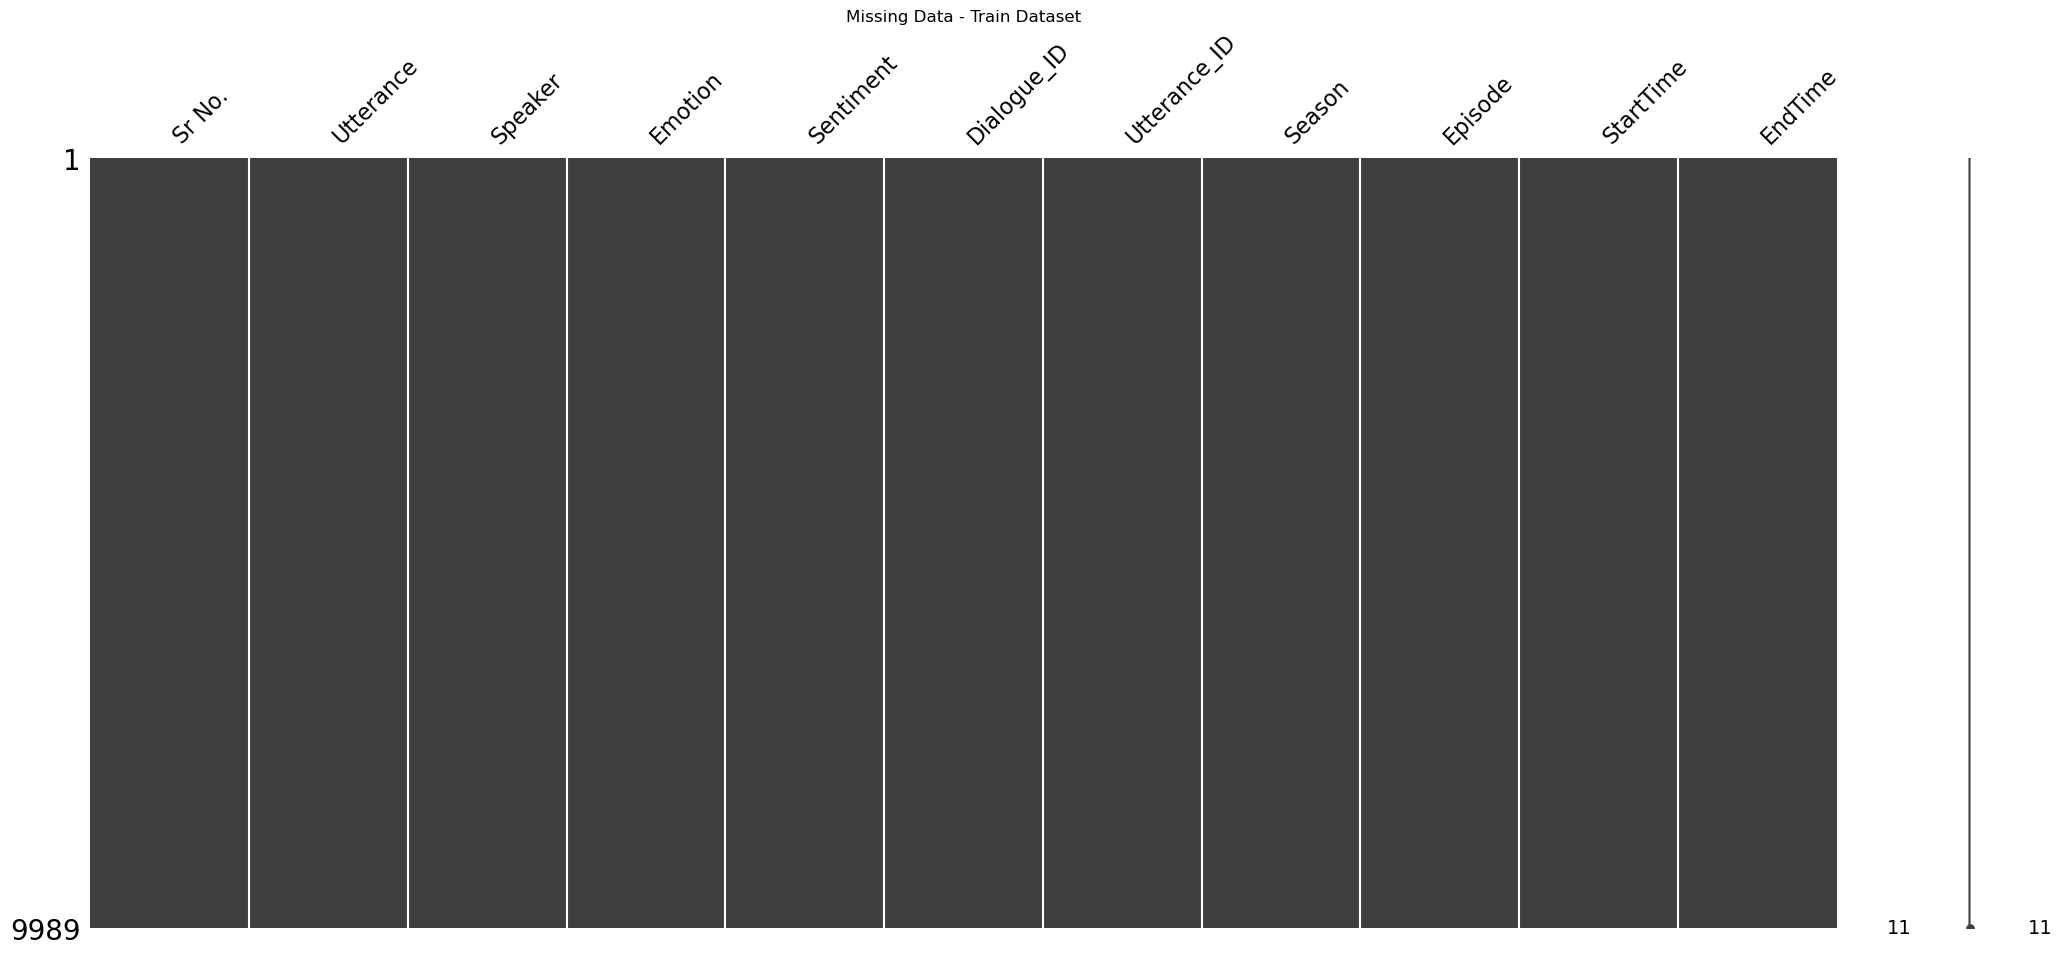

Missing data visualization for dev dataset:


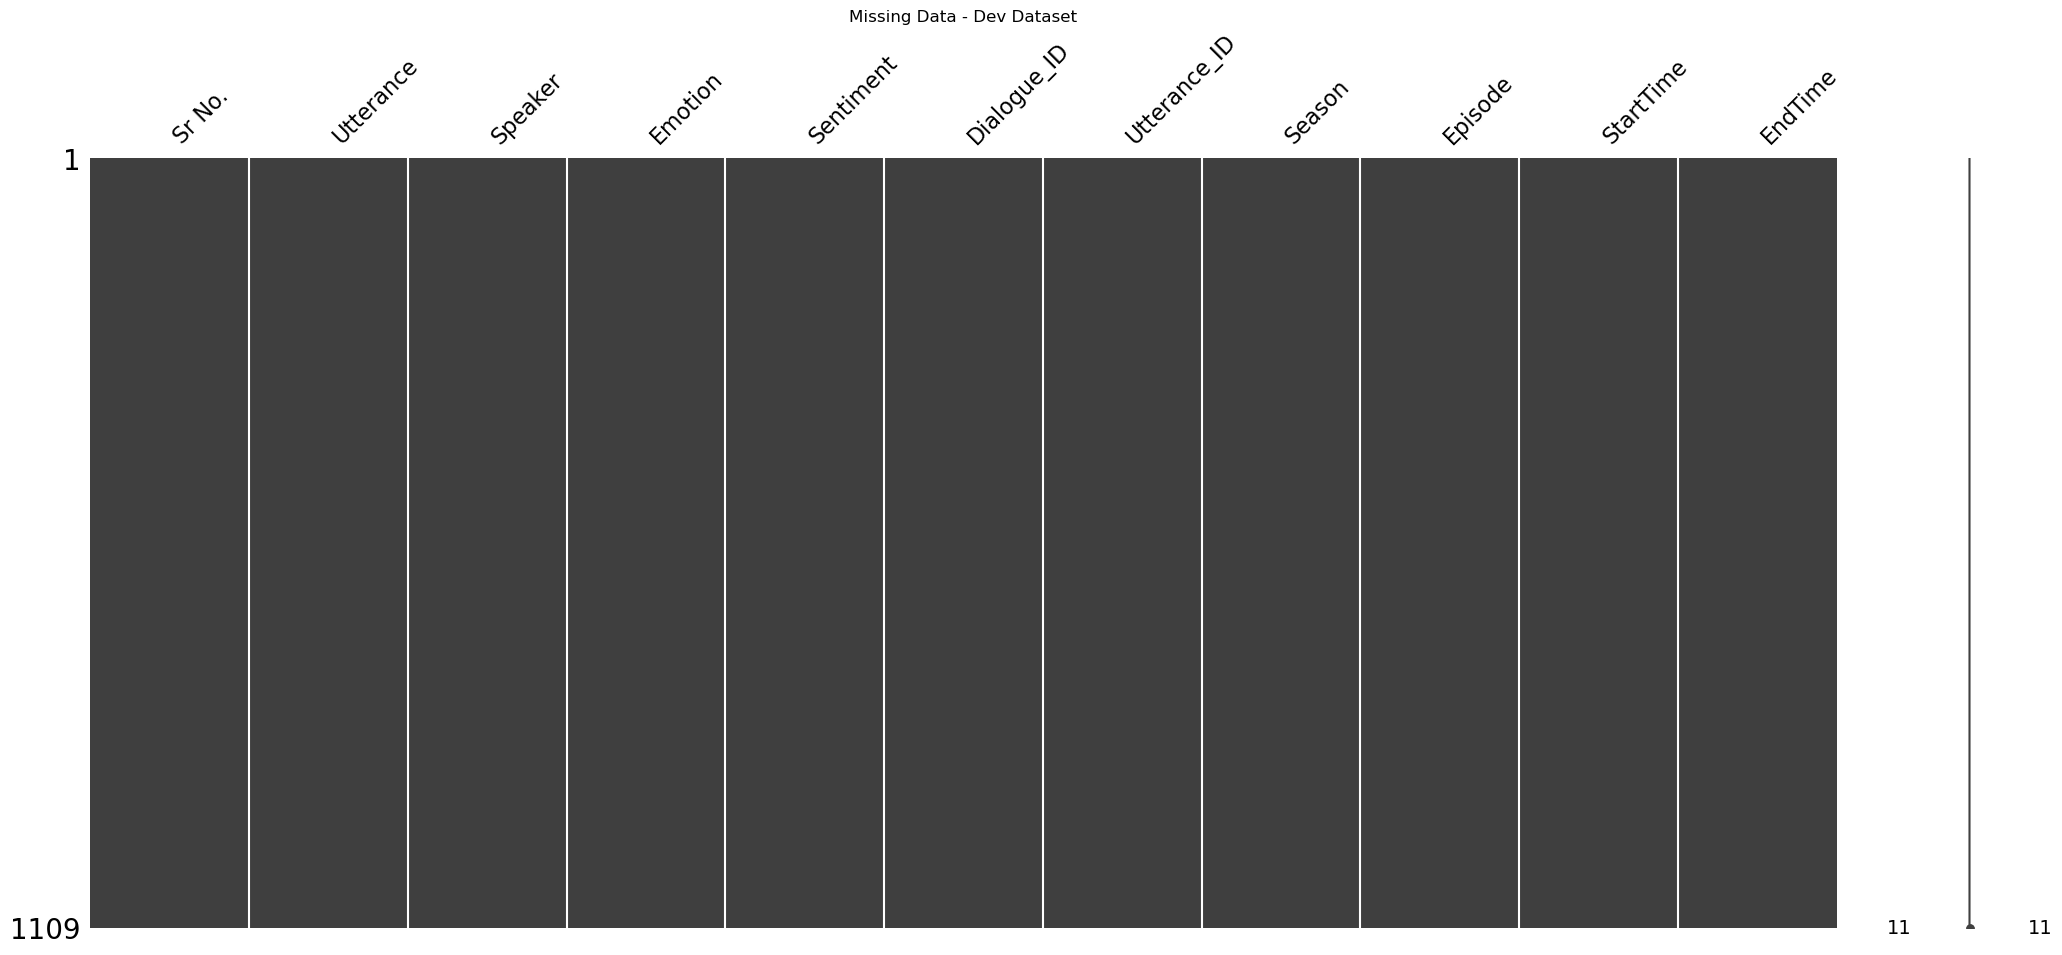

Missing data visualization for test dataset:


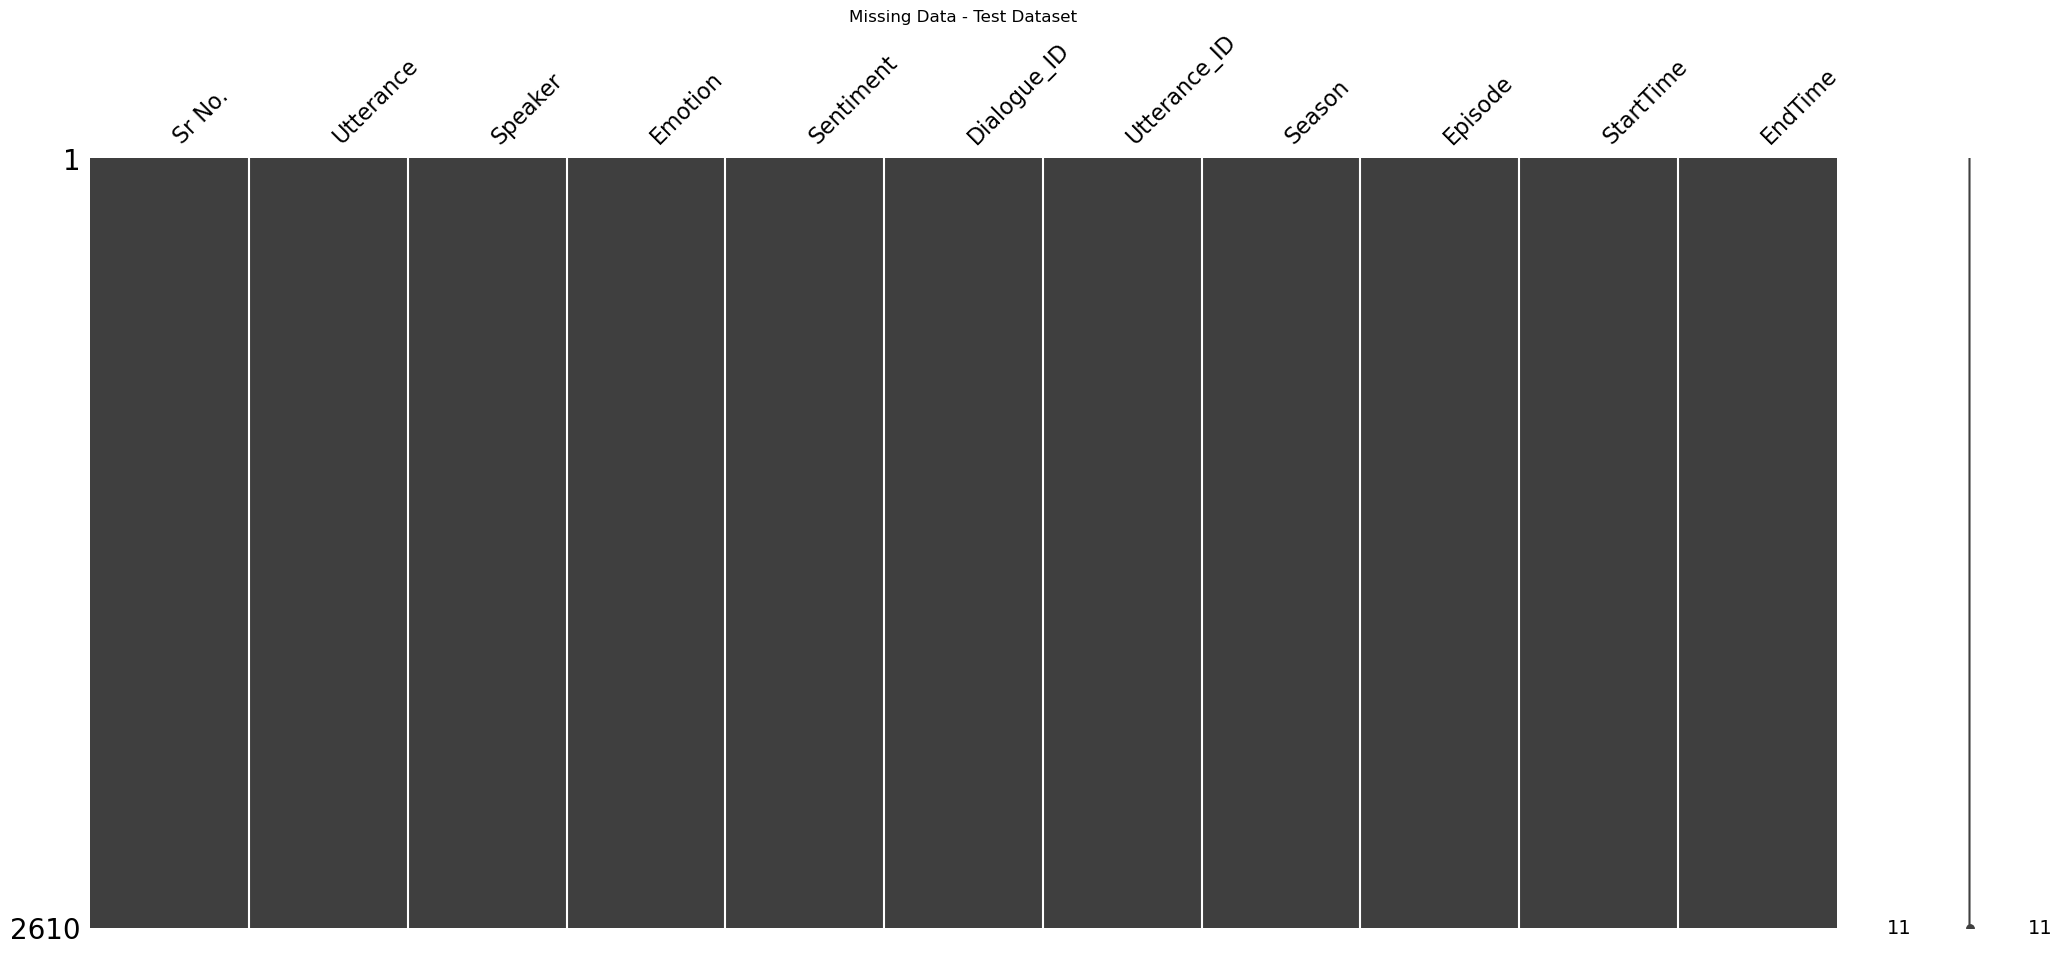

In [9]:
import missingno as msno
import matplotlib.pyplot as plt

# Visualize missing data in the train dataset
print("Missing data visualization for train dataset:")
msno.matrix(train_df)
plt.title("Missing Data - Train Dataset")
plt.show()

# Visualize missing data in the dev dataset
print("Missing data visualization for dev dataset:")
msno.matrix(dev_df)
plt.title("Missing Data - Dev Dataset")
plt.show()

# Visualize missing data in the test dataset
print("Missing data visualization for test dataset:")
msno.matrix(test_df)
plt.title("Missing Data - Test Dataset")
plt.show()

Correlation of missing data in train dataset:


C:\ProgramData\anaconda3\lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
C:\ProgramData\anaconda3\lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


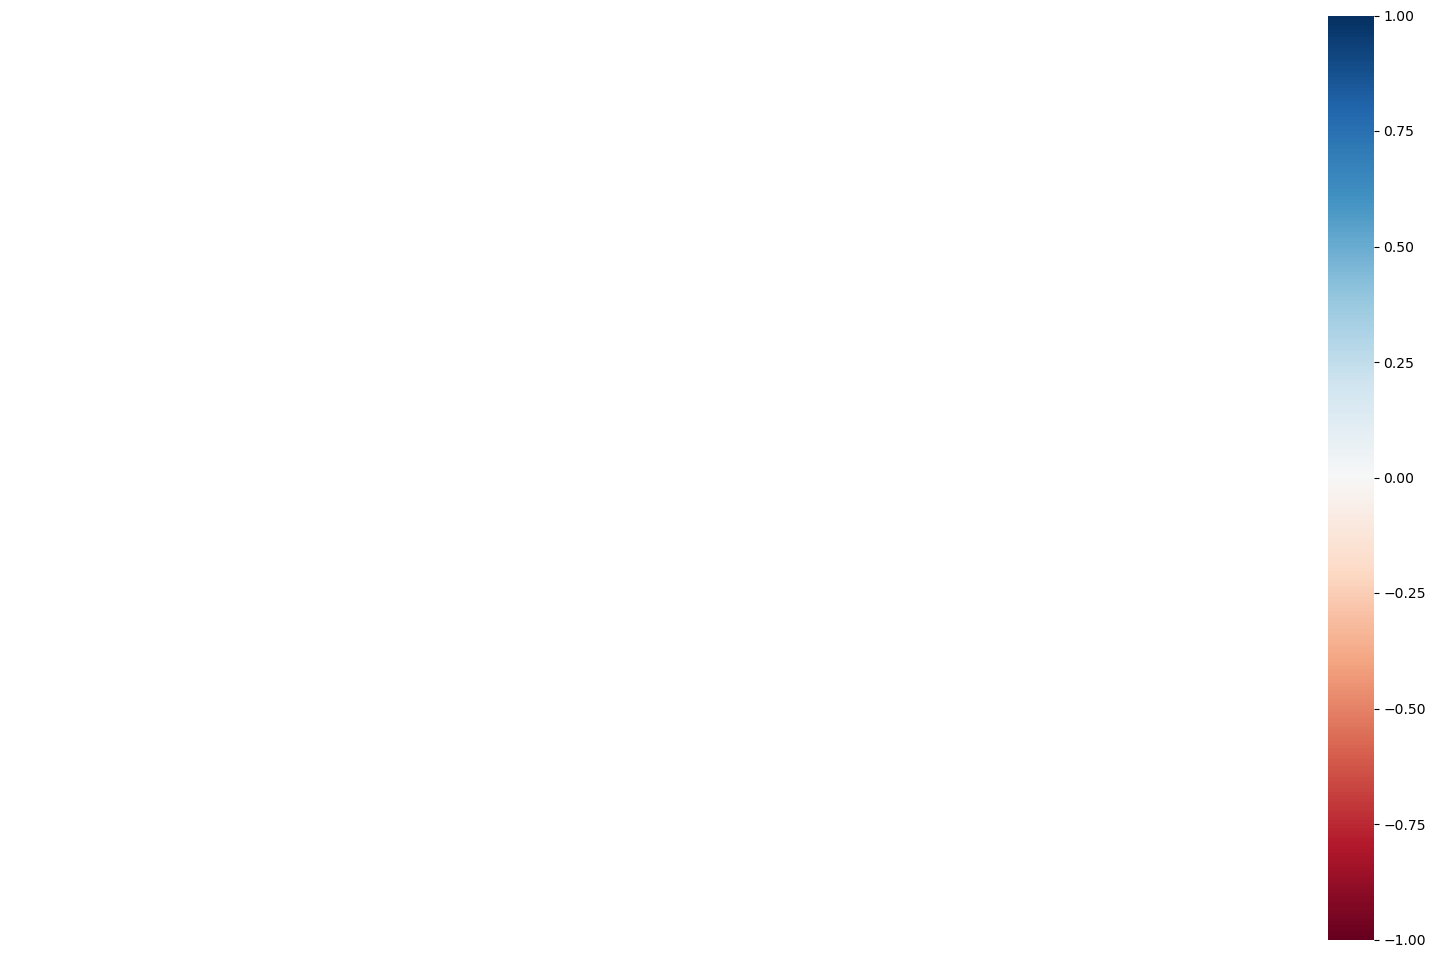

Correlation of missing data in dev dataset:


C:\ProgramData\anaconda3\lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
C:\ProgramData\anaconda3\lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


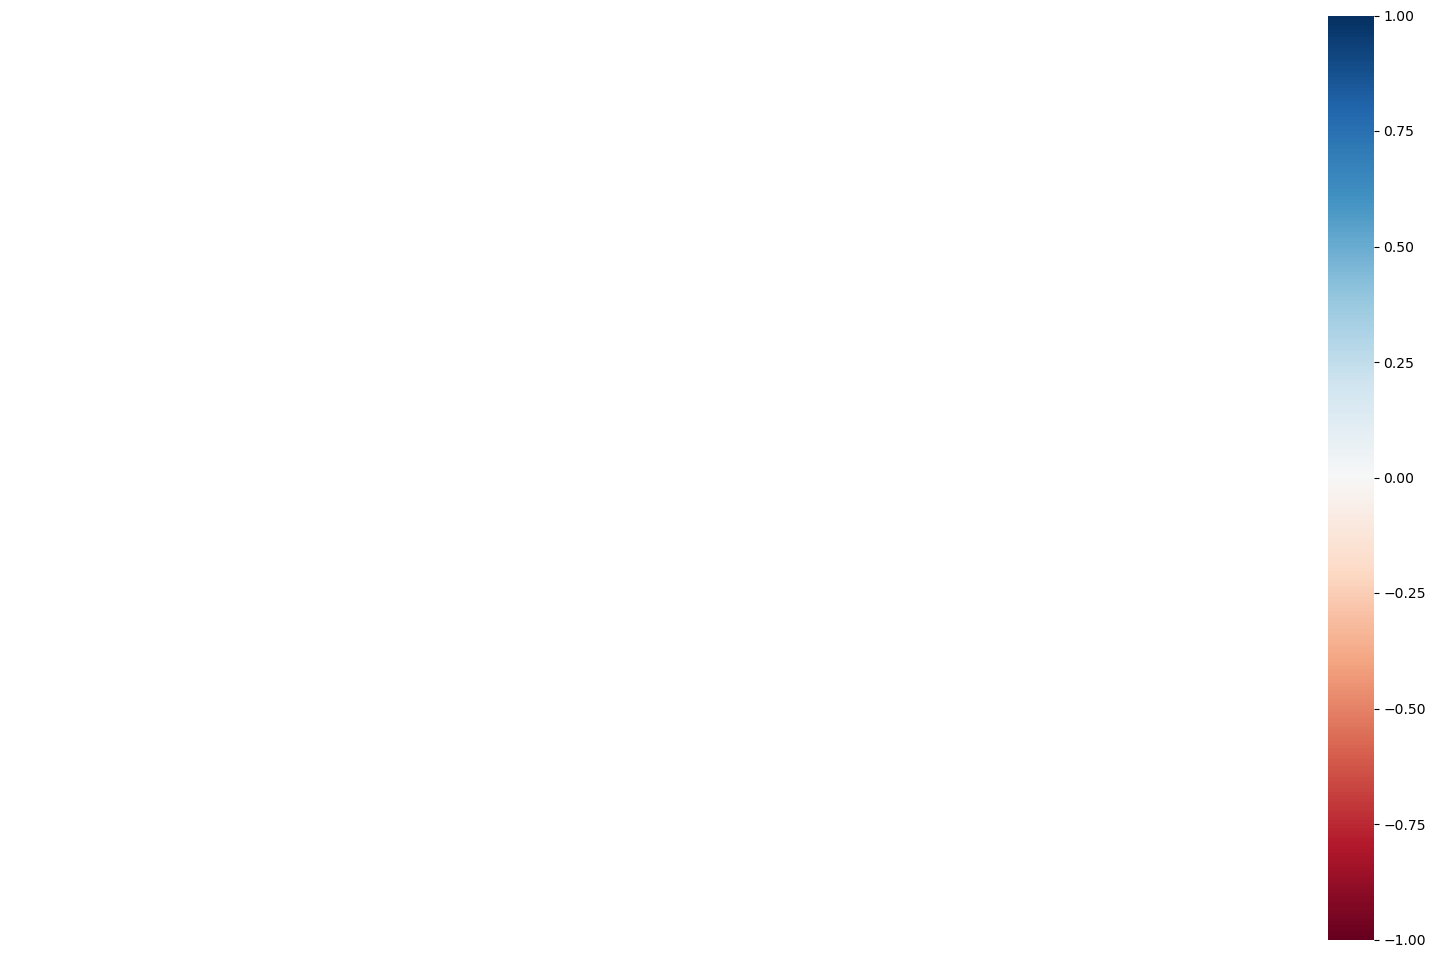

Correlation of missing data in test dataset:


C:\ProgramData\anaconda3\lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
C:\ProgramData\anaconda3\lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


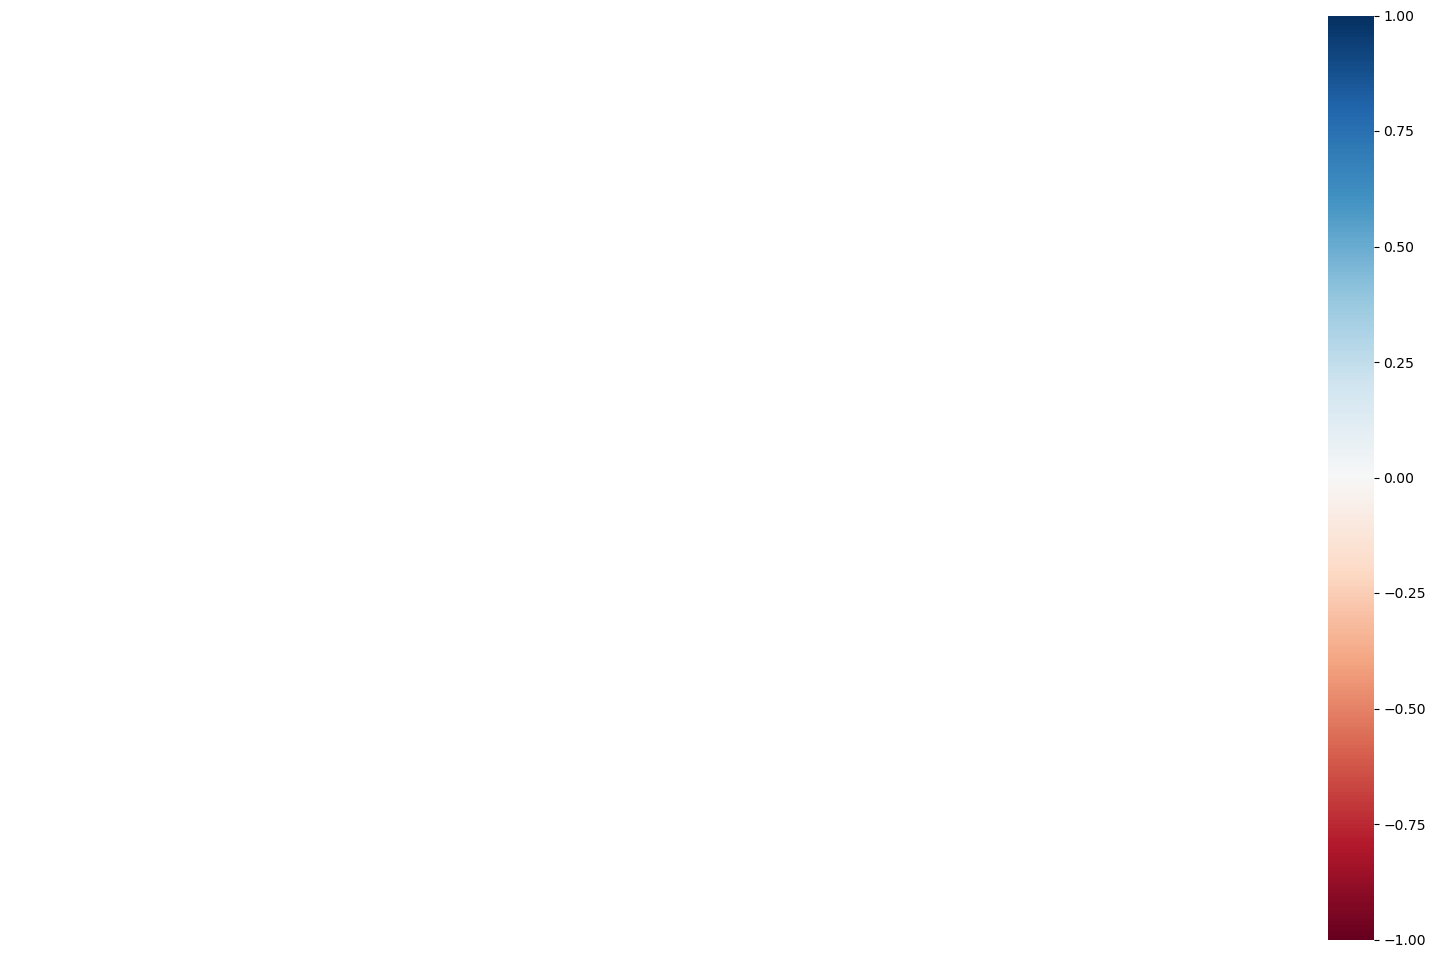

In [10]:
# Heatmap of missing data correlation for train dataset
print("Correlation of missing data in train dataset:")
msno.heatmap(train_df)
plt.show()

# Heatmap of missing data correlation for dev dataset
print("Correlation of missing data in dev dataset:")
msno.heatmap(dev_df)
plt.show()

# Heatmap of missing data correlation for test dataset
print("Correlation of missing data in test dataset:")
msno.heatmap(test_df)
plt.show()

## Detect Outliers

Common Methods for Outlier Detection
Using Z-Scores:

The Z-score method helps identify how far a data point is from the mean, measured in standard deviations. Data points with a Z-score greater than a threshold (commonly ±3) are considered outliers.
Using the Interquartile Range (IQR):

The IQR method identifies outliers by looking at values that fall below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR, where Q1 is the first quartile and Q3 is the third quartile.
This method is particularly useful for skewed data.
Visualization Techniques:

Box plots and scatter plots are useful for visualizing outliers in numerical data.

### Detect Outliers Using Z-Scores

In [11]:
from scipy.stats import zscore

# Calculate Z-scores for numerical columns
z_scores = train_df.select_dtypes(include=[np.number]).apply(zscore)

# Set threshold (commonly 3 or -3 for outliers)
threshold = 3
outliers_zscore = (z_scores > threshold) | (z_scores < -threshold)

# Print columns with outliers based on Z-score
print("Outliers detected using Z-score method:")
for col in outliers_zscore.columns:
    print(f"{col}: {outliers_zscore[col].sum()} outliers")

Outliers detected using Z-score method:
Sr No.: 0 outliers
Dialogue_ID: 0 outliers
Utterance_ID: 19 outliers
Season: 0 outliers
Episode: 0 outliers


### Detect Outliers Using IQR Method

In [12]:
# Calculate IQR for numerical columns
Q1 = train_df.quantile(0.25)
Q3 = train_df.quantile(0.75)
IQR = Q3 - Q1

# Define outlier threshold
outliers_iqr = ((train_df < (Q1 - 1.5 * IQR)) | (train_df > (Q3 + 1.5 * IQR)))

# Print columns with outliers based on IQR
print("\nOutliers detected using IQR method:")
for col in outliers_iqr.columns:
    print(f"{col}: {outliers_iqr[col].sum()} outliers")


Outliers detected using IQR method:
Dialogue_ID: 0 outliers
Emotion: 0 outliers
EndTime: 0 outliers
Episode: 0 outliers
Season: 0 outliers
Sentiment: 0 outliers
Speaker: 0 outliers
Sr No.: 0 outliers
StartTime: 0 outliers
Utterance: 0 outliers
Utterance_ID: 97 outliers


C:\Users\eradi\AppData\Local\Temp\ipykernel_20288\2298616733.py:2: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q1 = train_df.quantile(0.25)
C:\Users\eradi\AppData\Local\Temp\ipykernel_20288\2298616733.py:3: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q3 = train_df.quantile(0.75)
C:\Users\eradi\AppData\Local\Temp\ipykernel_20288\2298616733.py:7: FutureWarning: Automatic reindexing on DataFrame vs Series comparisons is deprecated and will raise ValueError in a future version. Do `left, right = left.align(right, axis=1, copy=False)` before e.g. `left == right`
  outliers_iqr = ((train_df < (Q1 - 1.5 * IQR)) | (train_df > (Q3 + 1.5 * IQR)

In [13]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


### Visualize Outliers Using Box Plots

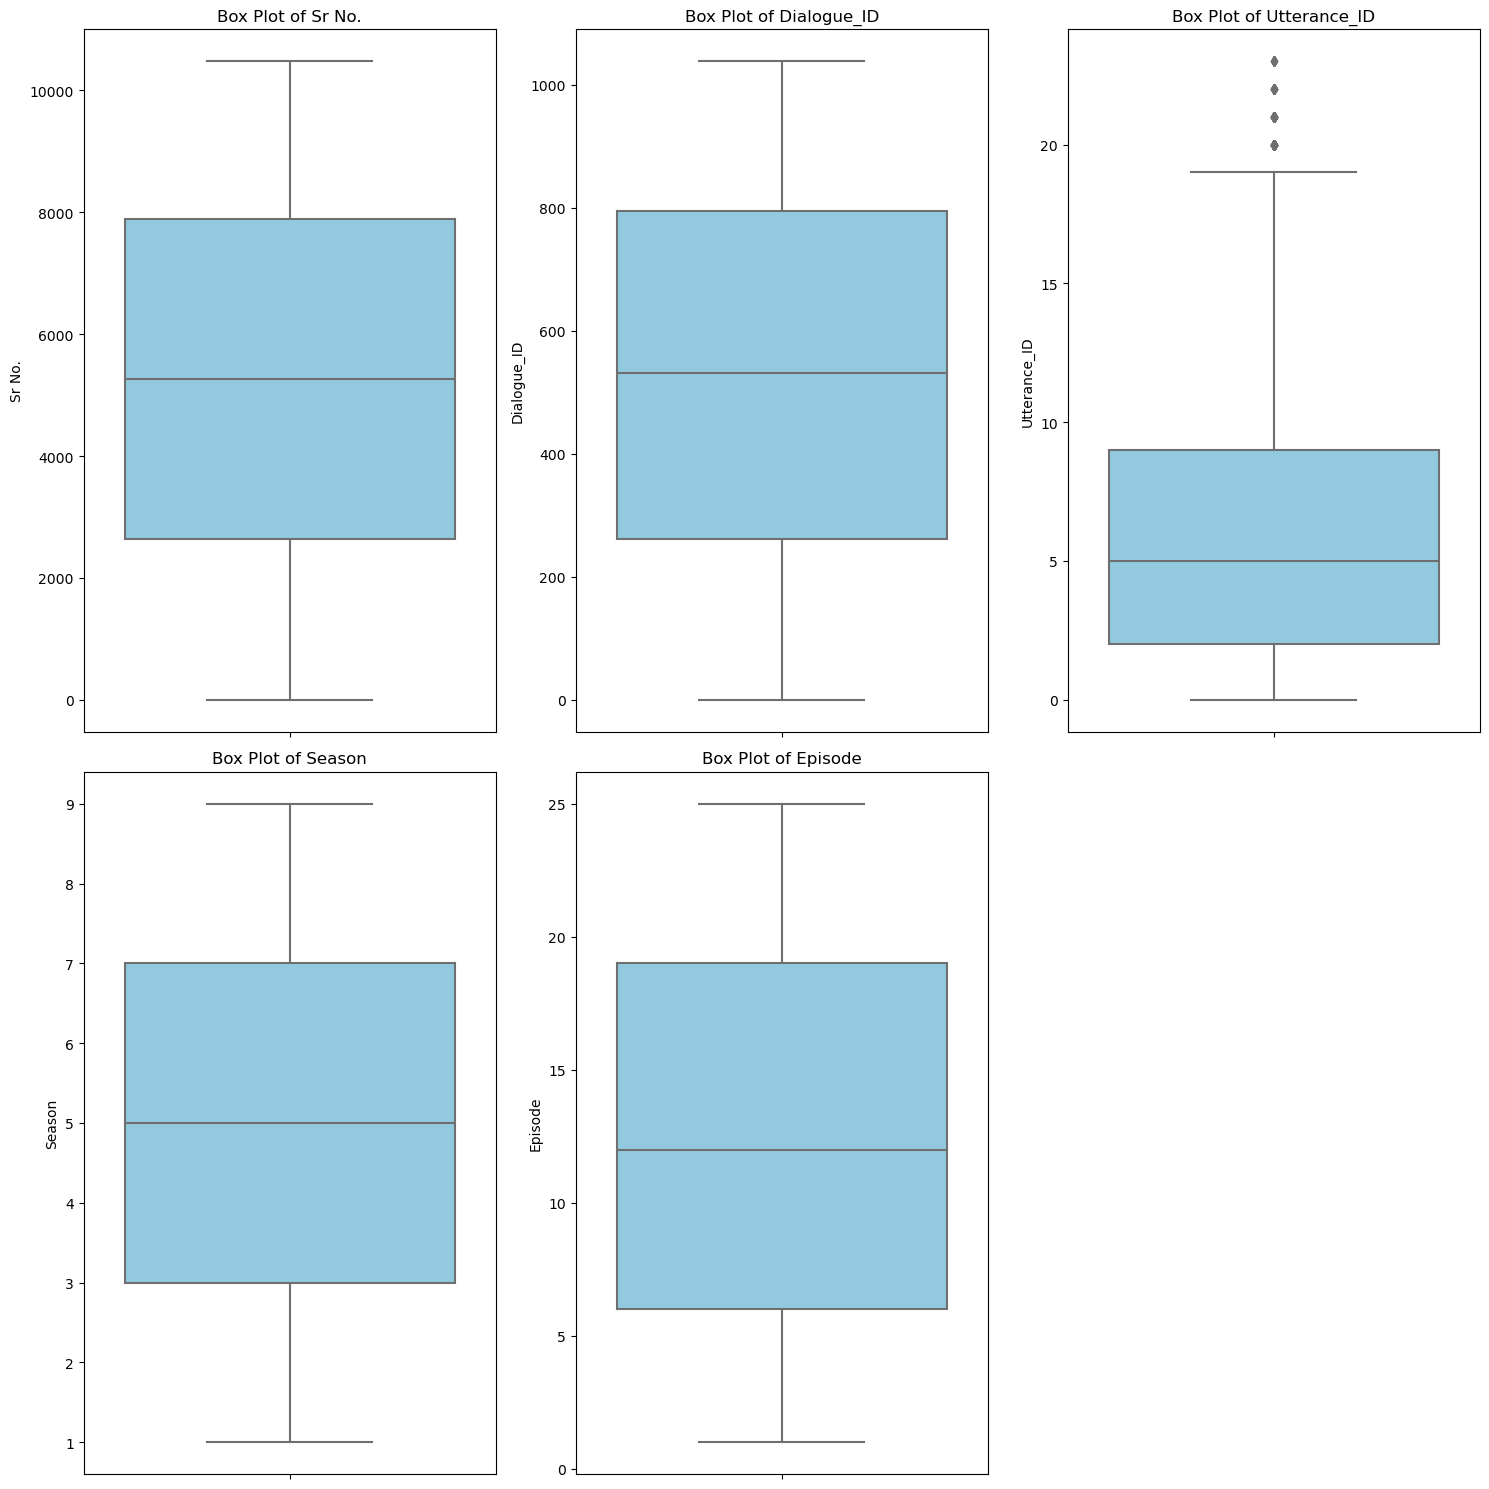

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure all numerical columns are available
numerical_columns = train_df.select_dtypes(include=[np.number]).columns

# Check if there are numerical columns to plot
if len(numerical_columns) > 0:
    # Set figure size
    plt.figure(figsize=(15, len(numerical_columns) * 3))

    # Loop through each numerical column
    for i, col in enumerate(numerical_columns, 1):
        plt.subplot(len(numerical_columns) // 3 + 1, 3, i)  # Dynamic grid size
        sns.boxplot(y=train_df[col], color="skyblue")  # Add color for better visuals
        plt.title(f"Box Plot of {col}")
        plt.ylabel(col)

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found in the dataset.")

### Outlier Analysis in Dev and Test Sets

Outliers detected in dev dataset using Z-score method (analysis only):
Sr No.: 0 outliers
Dialogue_ID: 0 outliers
Utterance_ID: 4 outliers
Season: 0 outliers
Episode: 0 outliers


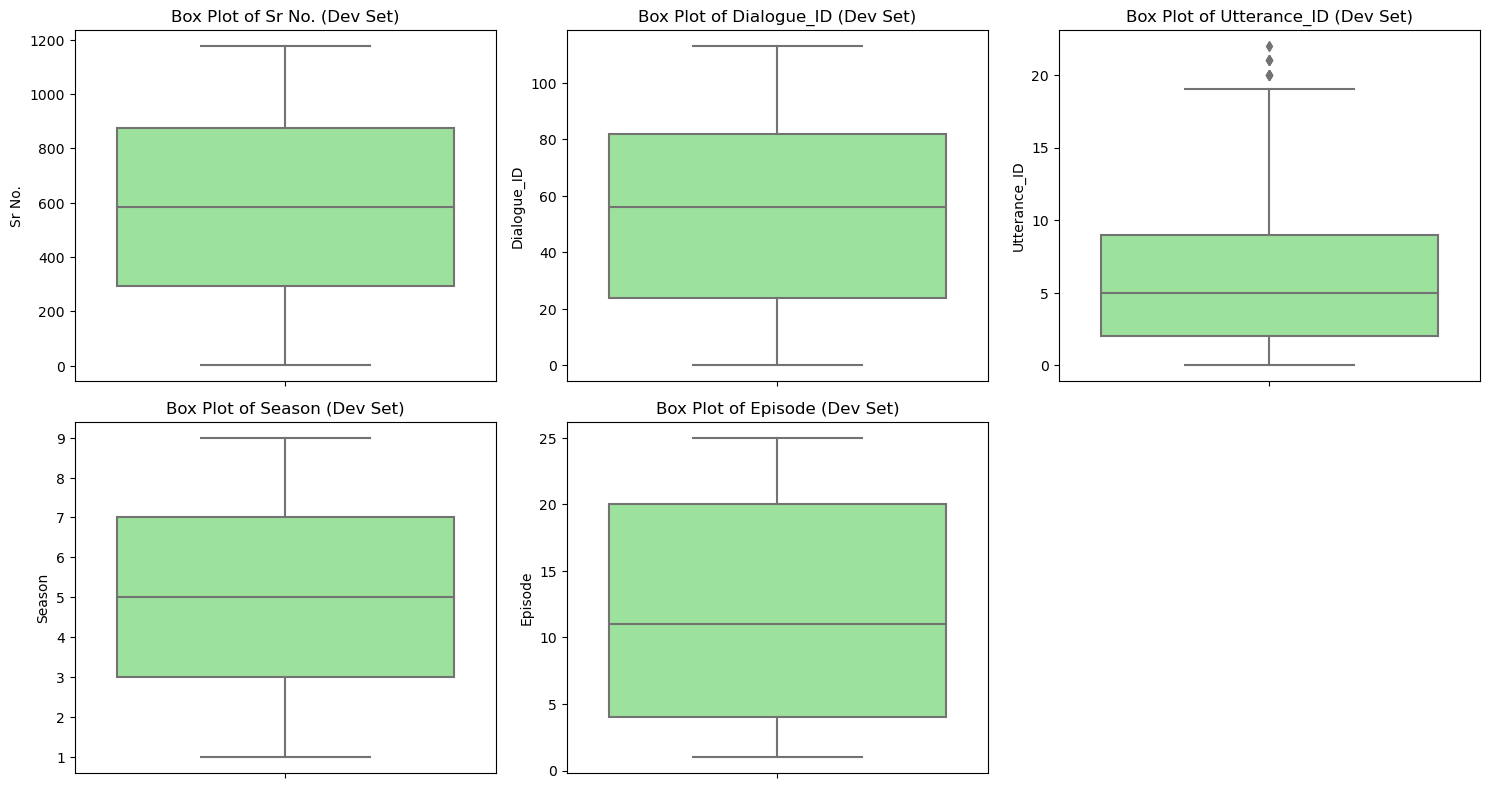

In [15]:
# Detect outliers in dev dataset using Z-score (for analysis purposes only)
z_scores_dev = dev_df.select_dtypes(include=[np.number]).apply(zscore)
outliers_zscore_dev = (z_scores_dev > threshold) | (z_scores_dev < -threshold)

print("Outliers detected in dev dataset using Z-score method (analysis only):")
for col in outliers_zscore_dev.columns:
    print(f"{col}: {outliers_zscore_dev[col].sum()} outliers")
    
# For dev dataset
plt.figure(figsize=(15, 8))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns) // 3 + 1, 3, i)
    sns.boxplot(y=dev_df[col], color='lightgreen')
    plt.title(f"Box Plot of {col} (Dev Set)")

plt.tight_layout()
plt.show()

C:\Users\eradi\AppData\Local\Temp\ipykernel_20288\1889714673.py:2: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q1_test = test_df.quantile(0.25)
C:\Users\eradi\AppData\Local\Temp\ipykernel_20288\1889714673.py:3: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q3_test = test_df.quantile(0.75)
C:\Users\eradi\AppData\Local\Temp\ipykernel_20288\1889714673.py:5: FutureWarning: Automatic reindexing on DataFrame vs Series comparisons is deprecated and will raise ValueError in a future version. Do `left, right = left.align(right, axis=1, copy=False)` before e.g. `left == right`
  outliers_iqr_test = ((test_df < (Q1_test - 1.5 * IQR_test)) | (test_


Outliers detected in test dataset using IQR method (analysis only):
Dialogue_ID: 0 outliers
Emotion: 0 outliers
EndTime: 0 outliers
Episode: 0 outliers
Season: 0 outliers
Sentiment: 0 outliers
Speaker: 0 outliers
Sr No.: 0 outliers
StartTime: 0 outliers
Utterance: 0 outliers
Utterance_ID: 33 outliers


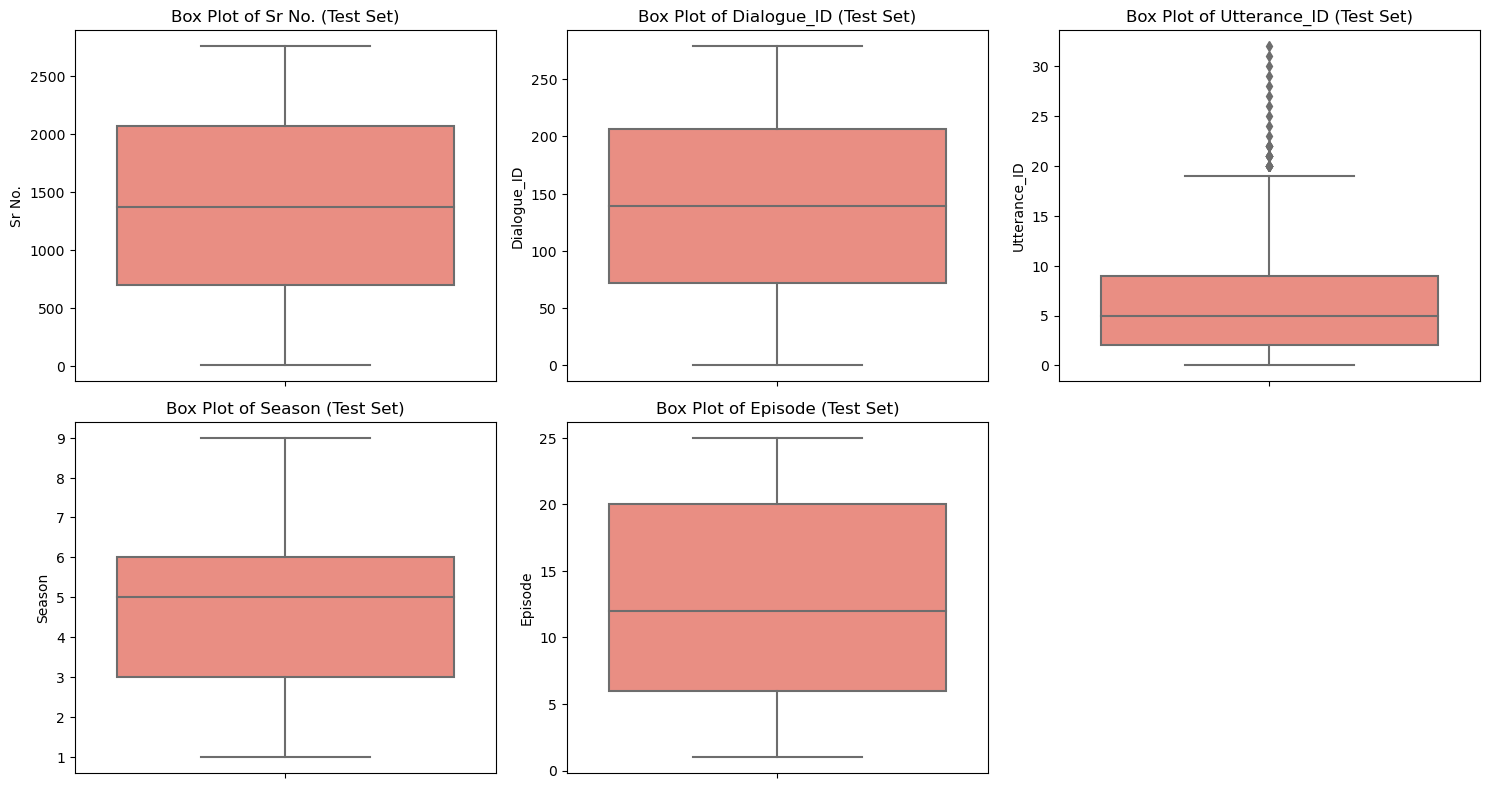

In [16]:
# Detect outliers in test dataset using IQR (for analysis purposes only)
Q1_test = test_df.quantile(0.25)
Q3_test = test_df.quantile(0.75)
IQR_test = Q3_test - Q1_test
outliers_iqr_test = ((test_df < (Q1_test - 1.5 * IQR_test)) | (test_df > (Q3_test + 1.5 * IQR_test)))

print("\nOutliers detected in test dataset using IQR method (analysis only):")
for col in outliers_iqr_test.columns:
    print(f"{col}: {outliers_iqr_test[col].sum()} outliers")
    
# For test dataset
plt.figure(figsize=(15, 8))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns) // 3 + 1, 3, i)
    sns.boxplot(y=test_df[col], color='salmon')
    plt.title(f"Box Plot of {col} (Test Set)")

plt.tight_layout()
plt.show()

## Encode Categorical Variables

Types of Encoding Methods
Label Encoding:

Assigns a unique integer to each category.
Suitable for ordinal (ordered) categorical data.
One-Hot Encoding:

Converts each category into a binary vector, with one column per category.
Suitable for nominal (unordered) categorical data, especially when there are a limited number of categories.

### One-Hot Encoding with pd.get_dummies() (Recommended for Nominal Data)

In [17]:
# One-hot encoding on the 'Emotion' column in each dataset
train_encoded = pd.get_dummies(train_df, columns=['Emotion'], drop_first=True)
dev_encoded = pd.get_dummies(dev_df, columns=['Emotion'], drop_first=True)
test_encoded = pd.get_dummies(test_df, columns=['Emotion'], drop_first=True)

# Display the first few rows of the encoded train dataset
print("One-hot encoded train dataset:")
print(train_encoded.head())

One-hot encoded train dataset:
   Sr No.                                          Utterance          Speaker  \
0       1  also I was the point person on my companys tr...         Chandler   
1       2                   You mustve had your hands full.  The Interviewer   
2       3                            That I did. That I did.         Chandler   
3       4      So lets talk a little bit about your duties.  The Interviewer   
4       5                             My duties?  All right.         Chandler   

  Sentiment  Dialogue_ID  Utterance_ID  Season  Episode     StartTime  \
0   neutral            0             0       8       21  00:16:16,059   
1   neutral            0             1       8       21  00:16:21,940   
2   neutral            0             2       8       21  00:16:23,442   
3   neutral            0             3       8       21  00:16:26,820   
4  positive            0             4       8       21  00:16:34,452   

        EndTime  Emotion_disgust  Emotion_f

### Label Encoding (for Ordinal Data)

In [18]:
from sklearn.preprocessing import LabelEncoder

# Example of label encoding an ordinal feature (use if you have ordered categories)
label_encoder = LabelEncoder()

# Assume 'Emotion' is ordinal in this example
train_df['Emotion'] = label_encoder.fit_transform(train_df['Emotion'])
dev_df['Emotion'] = label_encoder.transform(dev_df['Emotion'])
test_df['Emotion'] = label_encoder.transform(test_df['Emotion'])

# Display the first few rows of the label encoded train dataset
print("Label encoded train dataset:")
print(train_df.head())

Label encoded train dataset:
   Sr No.                                          Utterance          Speaker  \
0       1  also I was the point person on my companys tr...         Chandler   
1       2                   You mustve had your hands full.  The Interviewer   
2       3                            That I did. That I did.         Chandler   
3       4      So lets talk a little bit about your duties.  The Interviewer   
4       5                             My duties?  All right.         Chandler   

   Emotion Sentiment  Dialogue_ID  Utterance_ID  Season  Episode  \
0        4   neutral            0             0       8       21   
1        4   neutral            0             1       8       21   
2        4   neutral            0             2       8       21   
3        4   neutral            0             3       8       21   
4        6  positive            0             4       8       21   

      StartTime       EndTime  
0  00:16:16,059  00:16:21,731  
1  00:16:21

###  Handling Other Categorical Columns

In [19]:
# Identify categorical columns
categorical_columns = train_df.select_dtypes(include=['object']).columns

# One-hot encode all categorical columns
train_encoded = pd.get_dummies(train_df, columns=categorical_columns, drop_first=True)
dev_encoded = pd.get_dummies(dev_df, columns=categorical_columns, drop_first=True)
test_encoded = pd.get_dummies(test_df, columns=categorical_columns, drop_first=True)

In [20]:
# Display the first few rows of the encoded train dataset
print("One-hot encoded train dataset:")
print(train_encoded.head())

One-hot encoded train dataset:
   Sr No.  Emotion  Dialogue_ID  Utterance_ID  Season  Episode  \
0       1        4            0             0       8       21   
1       2        4            0             1       8       21   
2       3        4            0             2       8       21   
3       4        4            0             3       8       21   
4       5        6            0             4       8       21   

   Utterance_"Benefits lapsed."  Utterance_"Happy birthday to you!"  \
0                             0                                   0   
1                             0                                   0   
2                             0                                   0   
3                             0                                   0   
4                             0                                   0   

   Utterance_"Heating device."  \
0                            0   
1                            0   
2                            0   
3        

In [21]:
# Display the first few rows of the label encoded train dataset
print("Label encoded train dataset:")
print(train_df.head())

Label encoded train dataset:
   Sr No.                                          Utterance          Speaker  \
0       1  also I was the point person on my companys tr...         Chandler   
1       2                   You mustve had your hands full.  The Interviewer   
2       3                            That I did. That I did.         Chandler   
3       4      So lets talk a little bit about your duties.  The Interviewer   
4       5                             My duties?  All right.         Chandler   

   Emotion Sentiment  Dialogue_ID  Utterance_ID  Season  Episode  \
0        4   neutral            0             0       8       21   
1        4   neutral            0             1       8       21   
2        4   neutral            0             2       8       21   
3        4   neutral            0             3       8       21   
4        6  positive            0             4       8       21   

      StartTime       EndTime  
0  00:16:16,059  00:16:21,731  
1  00:16:21

## Visualize Correlations

Steps to Visualize Correlations
Calculate the Correlation Matrix:

Use corr() to compute the pairwise correlation of columns in the dataset.
Focus on numerical features (categorical variables should be encoded first, as you’ve done in Step 5).
Create a Heatmap:

Heatmaps help visualize the strength of correlations, with color gradients indicating positive or negative relationships.

### Code to Visualize Correlations

C:\Users\eradi\AppData\Local\Temp\ipykernel_20288\2414317246.py:5: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = train_encoded.corr()


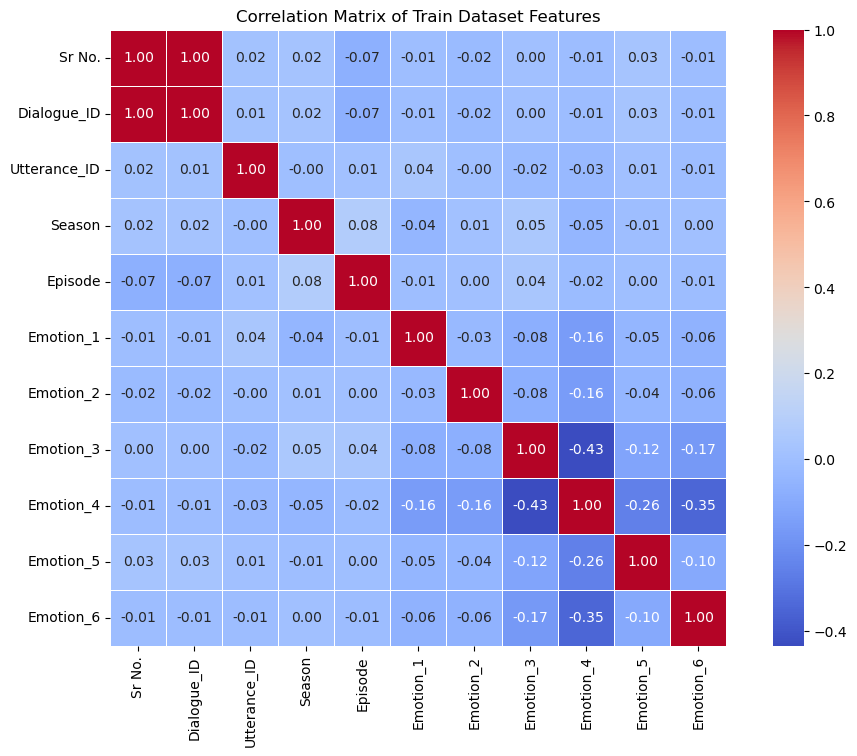

In [22]:
# Example encoding step (assuming train_df is already loaded)
train_encoded = pd.get_dummies(train_df, columns=['Emotion'], drop_first=True)

# Calculate the correlation matrix
corr_matrix = train_encoded.corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=.5)
plt.title("Correlation Matrix of Train Dataset Features")
plt.show()

### Code for Correlation Heatmap in dev_encoded and test_encoded

C:\Users\eradi\AppData\Local\Temp\ipykernel_20288\3220095092.py:12: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix_dev = dev_encoded.corr()


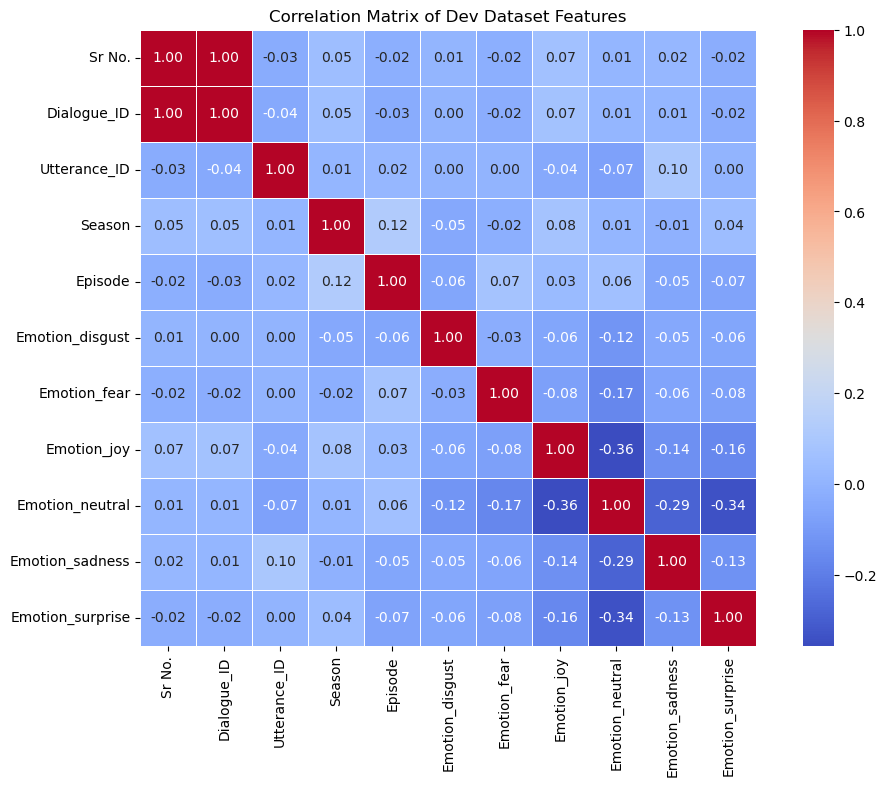

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the development dataset
dev_df = pd.read_csv(r'D:\ML & AI\Main Research\MELD\dev\dev_sent_emo.csv')

# Step 2: One-hot encode the 'Emotion' column
dev_encoded = pd.get_dummies(dev_df, columns=['Emotion'], drop_first=True)

# Step 3: Calculate the correlation matrix
corr_matrix_dev = dev_encoded.corr()

# Step 4: Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix_dev, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=.5)
plt.title("Correlation Matrix of Dev Dataset Features")
plt.show()


C:\Users\eradi\AppData\Local\Temp\ipykernel_20288\1279902423.py:12: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix_test = test_encoded.corr()


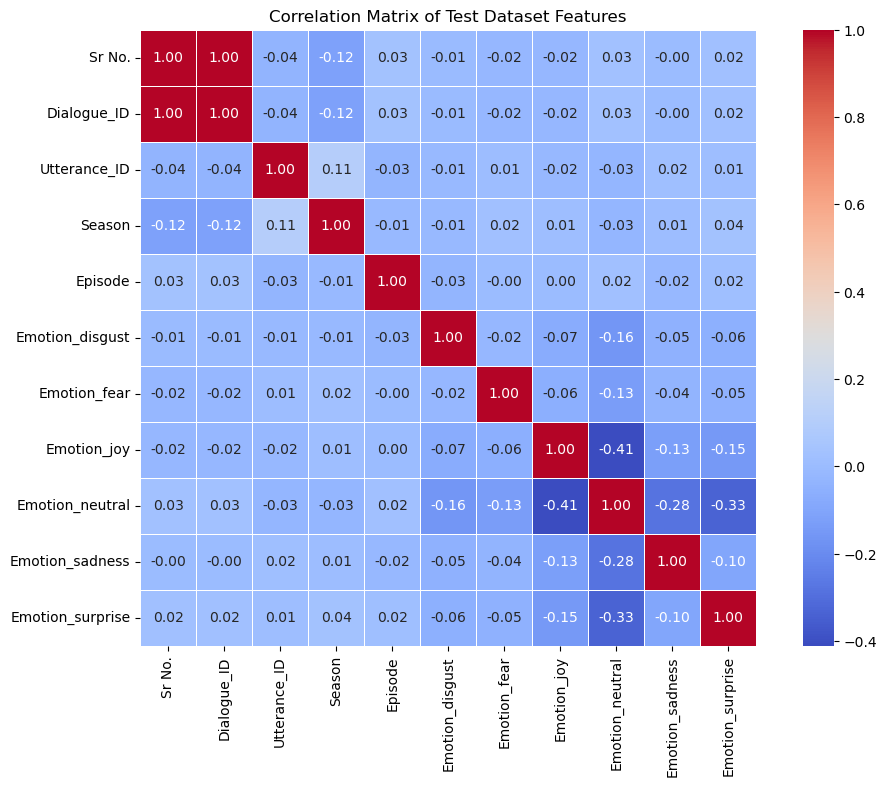

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the test dataset
test_df = pd.read_csv(r'D:\ML & AI\Main Research\MELD\test\test_sent_emo.csv')

# Step 2: One-hot encode the 'Emotion' column
test_encoded = pd.get_dummies(test_df, columns=['Emotion'], drop_first=True)

# Step 3: Calculate the correlation matrix
corr_matrix_test = test_encoded.corr()

# Step 4: Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix_test, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=.5)
plt.title("Correlation Matrix of Test Dataset Features")
plt.show()


## Split the Data into Train and Test Sets

In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load your dataset (replace with your actual file path or data source)
df = pd.read_csv(r'D:\ML & AI\Main Research\MELD\test\test_sent_emo.csv')  

# Inspect the first few rows of the DataFrame to check its structure
print(df.head())

# Define features (X) and target (y)
X = df[['Utterance']]  # Assuming 'Utterance' is a column in your dataset
y = df['Sentiment']    # Assuming 'Sentiment' is a column in your dataset

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # Stratify to maintain class balance
)

# Check the split sizes
print(f"Training features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Test target shape: {y_test.shape}")

   Sr No.                                          Utterance Speaker  \
0       1  Why do all youre coffee mugs have numbers on ...    Mark   
1       2  Oh. Thats so Monica can keep track. That way ...  Rachel   
2       3                                       Y'know what?  Rachel   
3      19                     Come on, Lydia, you can do it.    Joey   
4      20                                              Push!    Joey   

    Emotion Sentiment  Dialogue_ID  Utterance_ID  Season  Episode  \
0  surprise  positive            0             0       3       19   
1     anger  negative            0             1       3       19   
2   neutral   neutral            0             2       3       19   
3   neutral   neutral            1             0       1       23   
4       joy  positive            1             1       1       23   

      StartTime       EndTime  
0  00:14:38,127  00:14:40,378  
1  00:14:40,629  00:14:47,385  
2  00:14:56,353  00:14:57,520  
3   0:10:44,769   0:10:4

In [26]:
# Check column names and data types
print(df.columns)
print(df.dtypes)

# Check for missing values
print(df.isnull().sum())

Index(['Sr No.', 'Utterance', 'Speaker', 'Emotion', 'Sentiment', 'Dialogue_ID',
       'Utterance_ID', 'Season', 'Episode', 'StartTime', 'EndTime'],
      dtype='object')
Sr No.           int64
Utterance       object
Speaker         object
Emotion         object
Sentiment       object
Dialogue_ID      int64
Utterance_ID     int64
Season           int64
Episode          int64
StartTime       object
EndTime         object
dtype: object
Sr No.          0
Utterance       0
Speaker         0
Emotion         0
Sentiment       0
Dialogue_ID     0
Utterance_ID    0
Season          0
Episode         0
StartTime       0
EndTime         0
dtype: int64


## Train the Model

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Step 1: Transform text data into numerical format using TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')  # Adjust max_features as needed
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train['Utterance'].values)
X_test_tfidf = tfidf_vectorizer.transform(X_test['Utterance'].values)

# Step 2: Initialize Logistic Regression
model = LogisticRegression(max_iter=1000)

# Step 3: Train the model
model.fit(X_train_tfidf, y_train)

# Step 4: Evaluate the model
y_pred = model.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Print detailed classification report
print(classification_report(y_test, y_pred))

Accuracy: 0.51
              precision    recall  f1-score   support

    negative       0.44      0.33      0.38       167
     neutral       0.54      0.73      0.62       251
    positive       0.49      0.27      0.35       104

    accuracy                           0.51       522
   macro avg       0.49      0.44      0.45       522
weighted avg       0.50      0.51      0.49       522



## Evaluate the Model

Accuracy: 0.51
Classification Report:
              precision    recall  f1-score   support

    negative       0.44      0.33      0.38       167
     neutral       0.54      0.73      0.62       251
    positive       0.49      0.27      0.35       104

    accuracy                           0.51       522
   macro avg       0.49      0.44      0.45       522
weighted avg       0.50      0.51      0.49       522



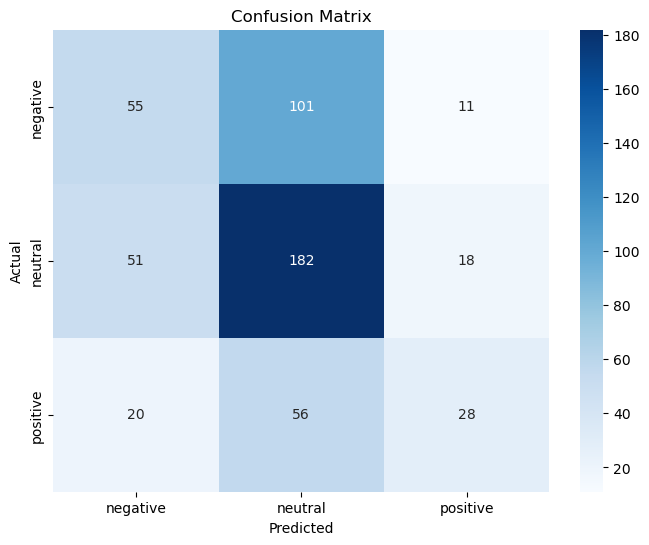

In [28]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Make predictions on the test set
y_pred = model.predict(X_test_tfidf)

# Step 2: Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Step 3: Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Step 4: Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Accessing Different Modalities (Text, Audio, Visual)

In [29]:
import pandas as pd

# Access and print text features
print("First few text features (Utterance):")
print(train_df['Utterance'].head())

# Access and print emotion labels
print("\nFirst few emotion labels:")
print(train_df['Emotion'].head())

# Access and print speaker information
print("\nFirst few speaker information:")
print(train_df['Speaker'].head())

First few text features (Utterance):
0    also I was the point person on my companys tr...
1                     You mustve had your hands full.
2                              That I did. That I did.
3        So lets talk a little bit about your duties.
4                               My duties?  All right.
Name: Utterance, dtype: object

First few emotion labels:
0    4
1    4
2    4
3    4
4    6
Name: Emotion, dtype: int32

First few speaker information:
0           Chandler
1    The Interviewer
2           Chandler
3    The Interviewer
4           Chandler
Name: Speaker, dtype: object


In [30]:
import pandas as pd

# Access and print text features
print("First few text features (Utterance) in the dev dataset:")
print(dev_df['Utterance'].head())

# Access and print emotion labels
print("\nFirst few emotion labels in the dev dataset:")
print(dev_df['Emotion'].head())

# Access and print speaker information
print("\nFirst few speaker information in the dev dataset:")
print(dev_df['Speaker'].head())

First few text features (Utterance) in the dev dataset:
0       Oh my God, hes lost it. Hes totally lost it.
1                                                What?
2    Or! Or, we could go to the bank, close our acc...
3                                     Youre a genius!
4              Aww, man, now we wont be bank buddies!
Name: Utterance, dtype: object

First few emotion labels in the dev dataset:
0     sadness
1    surprise
2     neutral
3         joy
4     sadness
Name: Emotion, dtype: object

First few speaker information in the dev dataset:
0      Phoebe
1      Monica
2        Ross
3    Chandler
4        Joey
Name: Speaker, dtype: object


In [31]:
import pandas as pd

# Access and print text features
print("First few text features (Utterance) in the test dataset:")
print(test_df['Utterance'].head())

# Access and print emotion labels
print("\nFirst few emotion labels in the test dataset:")
print(test_df['Emotion'].head())

# Access and print speaker information
print("\nFirst few speaker information in the test dataset:")
print(test_df['Speaker'].head())

First few text features (Utterance) in the test dataset:
0    Why do all youre coffee mugs have numbers on ...
1    Oh. Thats so Monica can keep track. That way ...
2                                         Y'know what?
3                       Come on, Lydia, you can do it.
4                                                Push!
Name: Utterance, dtype: object

First few emotion labels in the test dataset:
0    surprise
1       anger
2     neutral
3     neutral
4         joy
Name: Emotion, dtype: object

First few speaker information in the test dataset:
0      Mark
1    Rachel
2    Rachel
3      Joey
4      Joey
Name: Speaker, dtype: object


### Working with Other Modalities (Audio, Visual)

In [32]:
import os

# Define the root path where the MELD dataset is stored
main_dataset = r'D:\ML & AI\Main Research\MELD'

# Define file paths for train, dev, and test
train_path = os.path.join(main_dataset, 'train')
dev_path = os.path.join(main_dataset, 'dev')
test_path = os.path.join(main_dataset, 'test')

# Define paths to the audio directories within each set
train_audio_dir = os.path.join(train_path, 'train_audio')
dev_audio_dir = os.path.join(dev_path, 'dev_audio')
test_audio_dir = os.path.join(test_path, 'test_audio')

# List files in each audio directory with error handling
try:
    print(f"Files in the 'train_audio' directory: {os.listdir(train_audio_dir)}")
except FileNotFoundError:
    print("The 'train_audio' directory was not found.")

try:
    print(f"Files in the 'dev_audio' directory: {os.listdir(dev_audio_dir)}")
except FileNotFoundError:
    print("The 'dev_audio' directory was not found.")

try:
    print(f"Files in the 'test_audio' directory: {os.listdir(test_audio_dir)}")
except FileNotFoundError:
    print("The 'test_audio' directory was not found.")

# List files in the main MELD directory to verify if the folders exist
print("\nFiles in the main MELD directory:")
print(os.listdir(main_dataset))

# Check if test_audio directory exists
print("\nDoes the 'test_audio' directory exist?", os.path.exists(test_audio_dir))
print("\nContents of the 'test' directory:")
print(os.listdir(test_path))

Files in the 'train_audio' directory: ['dia0_utt0.mp3', 'dia0_utt1.mp3', 'dia0_utt10.mp3', 'dia0_utt11.mp3', 'dia0_utt12.mp3', 'dia0_utt13.mp3', 'dia0_utt2.mp3', 'dia0_utt3.mp3', 'dia0_utt4.mp3', 'dia0_utt5.mp3', 'dia0_utt6.mp3', 'dia0_utt7.mp3', 'dia0_utt8.mp3', 'dia0_utt9.mp3', 'dia1000_utt0.mp3', 'dia1000_utt1.mp3', 'dia1000_utt2.mp3', 'dia1000_utt3.mp3', 'dia1001_utt0.mp3', 'dia1001_utt1.mp3', 'dia1001_utt10.mp3', 'dia1001_utt11.mp3', 'dia1001_utt2.mp3', 'dia1001_utt3.mp3', 'dia1001_utt4.mp3', 'dia1001_utt5.mp3', 'dia1001_utt6.mp3', 'dia1001_utt7.mp3', 'dia1001_utt8.mp3', 'dia1001_utt9.mp3', 'dia1002_utt0.mp3', 'dia1002_utt1.mp3', 'dia1002_utt2.mp3', 'dia1002_utt3.mp3', 'dia1002_utt4.mp3', 'dia1002_utt5.mp3', 'dia1003_utt0.mp3', 'dia1003_utt1.mp3', 'dia1003_utt2.mp3', 'dia1003_utt3.mp3', 'dia1003_utt4.mp3', 'dia1003_utt5.mp3', 'dia1003_utt6.mp3', 'dia1003_utt7.mp3', 'dia1004_utt0.mp3', 'dia1004_utt1.mp3', 'dia1004_utt2.mp3', 'dia1005_utt0.mp3', 'dia1005_utt1.mp3', 'dia1005_utt10.mp

4    4710
3    1743
6    1205
0    1109
5     683
1     271
2     268
Name: Emotion, dtype: int64


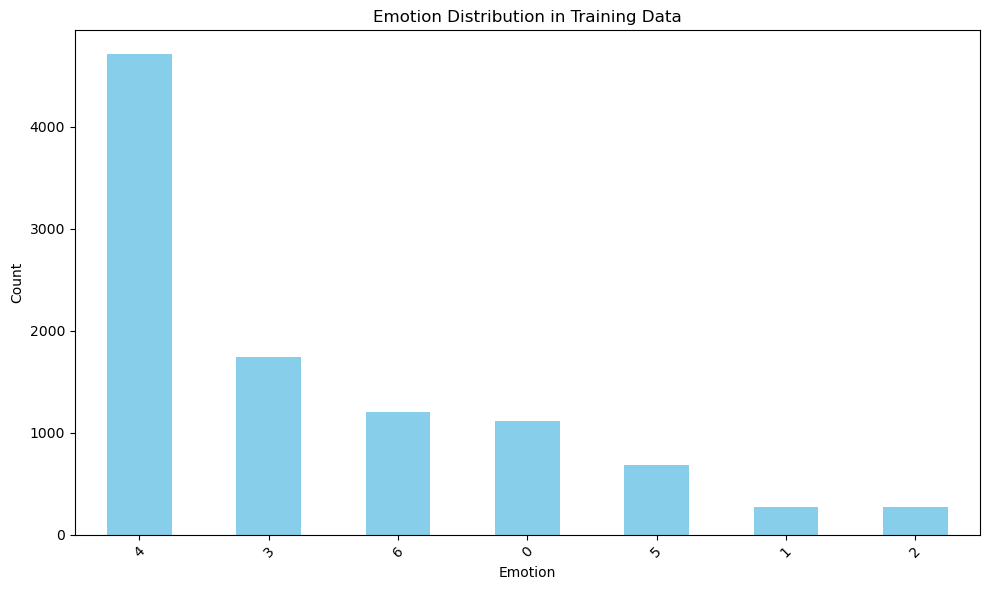

In [33]:
import matplotlib.pyplot as plt

# Compute the distribution of emotions in the training data
emotion_counts = train_df['Emotion'].value_counts()
print(emotion_counts)

# Plot the emotion distribution
plt.figure(figsize=(10, 6))  
emotion_counts.plot(kind='bar', color='skyblue')  
# Adding titles and labels
plt.title('Emotion Distribution in Training Data')
plt.xlabel('Emotion')
plt.ylabel('Count')

# Display the plot
plt.xticks(rotation=45) 
plt.tight_layout()  
plt.show()

#### Refined Code for Text Data Preprocessing

In [34]:
import pandas as pd
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Download the necessary NLTK data files (if not already downloaded)
import nltk
nltk.download('punkt')
nltk.download('stopwords')

# Sample data (assuming the 'train_df' contains your text data)
# train_df = pd.read_csv('your_data.csv')  # Load your dataset if not already loaded

# Step 1: Handle missing values (optional)
train_df = train_df.dropna(subset=['Utterance', 'Emotion'])  # Remove rows with missing 'Utterance' or 'Emotion'

# Step 2: Text Cleaning Function
def clean_text(text):
    # Lowercase the text
    text = text.lower()
    
    # Remove URLs, email addresses, and mentions (optional, based on your data)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # Remove URLs
    text = re.sub(r'\b\w+@\w+\.\w+\b', '', text)  # Remove email addresses
    text = re.sub(r'@\w+', '', text)  # Remove mentions
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove numbers (if not relevant for your analysis)
    text = re.sub(r'\d+', '', text)
    
    # Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Step 3: Apply text cleaning to the 'Utterance' column
train_df['Cleaned_Utterance'] = train_df['Utterance'].apply(clean_text)

# Step 4: Tokenization and Stopwords Removal
def tokenize_and_remove_stopwords(text):
    tokens = word_tokenize(text)  # Tokenize the text into words
    stop_words = set(stopwords.words('english'))  # Set of stopwords (English)
    filtered_tokens = [word for word in tokens if word not in stop_words]
    return " ".join(filtered_tokens)

# Step 5: Apply tokenization and stopword removal
train_df['Processed_Utterance'] = train_df['Cleaned_Utterance'].apply(tokenize_and_remove_stopwords)

# Step 6: Vectorization using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)  # Limit to top 5000 features
X = vectorizer.fit_transform(train_df['Processed_Utterance'])  # Apply TF-IDF vectorization
y = train_df['Emotion']  # Target variable

# Step 7: Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 8: Check the processed data and its dimensions
print(f"Processed Training Data (Features): \n{X_train.shape}")
print(f"Processed Test Data (Features): \n{X_test.shape}")

# Example: Display the first 5 processed utterances
print("\nFirst 5 processed utterances:")
print(train_df[['Utterance', 'Processed_Utterance']].head())

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\eradi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\eradi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Processed Training Data (Features): 
(7991, 5000)
Processed Test Data (Features): 
(1998, 5000)

First 5 processed utterances:
                                           Utterance  \
0  also I was the point person on my companys tr...   
1                   You mustve had your hands full.   
2                            That I did. That I did.   
3      So lets talk a little bit about your duties.   
4                             My duties?  All right.   

                                 Processed_Utterance  
0  also point person companys transition kl gr s...  
1                                 mustve hands full  
2                                                     
3                       lets talk little bit duties  
4                                       duties right  


In [35]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import pandas as pd

# Assuming 'train_df' is already defined and contains the columns 'Utterance' and 'Emotion'
# Example structure:
# train_df = pd.DataFrame({'Utterance': [...], 'Emotion': [...]})

# Parameters for tokenization and padding
max_words = 5000  # Maximum number of words to keep in the vocabulary
max_len = 100     # Maximum length of each sequence (padded/truncated)

# Initialize and fit the tokenizer on the text data
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(train_df['Utterance'])

# Convert the text data to sequences and pad them to a uniform length
train_sequences = tokenizer.texts_to_sequences(train_df['Utterance'])
train_padded = pad_sequences(train_sequences, maxlen=max_len)  # Ensure max_len is applied here

# Convert emotion labels to numerical values and one-hot encode them
emotion_mapping = {label: idx for idx, label in enumerate(train_df['Emotion'].unique())}
train_labels = [emotion_mapping[label] for label in train_df['Emotion']]
train_labels = to_categorical(train_labels, num_classes=len(emotion_mapping))

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(train_padded, train_labels, test_size=0.2, random_state=42)

# Print the shape of the training and validation datasets
print(f"Training samples: {X_train.shape}, Validation samples: {X_val.shape}")

Training samples: (7991, 100), Validation samples: (1998, 100)


In [36]:
print("Shape of train_padded:", train_padded.shape)
print("Shape of X_train:", X_train.shape)
print("Shape of X_val:", X_val.shape)

Shape of train_padded: (9989, 100)
Shape of X_train: (7991, 100)
Shape of X_val: (1998, 100)


#### Refined Code for Building the LSTM Model

In [37]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping

# Define model parameters
embedding_dim = 100  # Dimension of the embedding vector
max_words = 5000     # Size of the vocabulary
max_len = 100        # Length of the padded sequences
num_classes = len(emotion_mapping)  # Number of emotion classes

# Build the LSTM model
model = Sequential()

# Embedding layer to convert word indices into word vectors
model.add(Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len))

# LSTM layer to process the sequence data
model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2, return_sequences=True))

# Global Average Pooling to summarize the features after the LSTM
model.add(GlobalAveragePooling1D())

# Fully connected (Dense) layer
model.add(Dense(64, activation='relu'))

# Dropout layer to prevent overfitting
model.add(Dropout(0.5))

# Output layer with softmax activation for multi-class classification
model.add(Dense(num_classes, activation='softmax'))

# Compile the model with categorical crossentropy loss and adam optimizer
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# Display the model summary
model.summary()

# Callback for early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=3, verbose=1, restore_best_weights=True)

# Train the model
history = model.fit(X_train, y_train, 
                    epochs=10, 
                    batch_size=64, 
                    validation_data=(X_val, y_val), 
                    callbacks=[early_stop])

# Print the training history (optional)
print("Training History:")
print(history.history)

# Evaluate the model on the validation data
val_loss, val_accuracy = model.evaluate(X_val, y_val)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 100, 100)          500000    
                                                                 
 lstm (LSTM)                 (None, 100, 128)          117248    
                                                                 
 global_average_pooling1d (G  (None, 128)              0         
 lobalAveragePooling1D)                                          
                                                                 
 dense (Dense)               (None, 64)                8256      
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 7)                 455       
                                                        

In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
import tensorflow as tf

# Parameters for the model
max_words = 5000          # Vocabulary size
embedding_dim = 128       # Embedding dimension size
max_len = 100             # Maximum sequence length

# Build the LSTM model
model = Sequential()

# Add the Embedding layer
model.add(Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len, mask_zero=True))

# Add the LSTM layer
model.add(LSTM(64, return_sequences=False))

# Add the Dropout layer
model.add(Dropout(0.3))

# Add the Dense layer
model.add(Dense(32, activation='relu'))

# Add the Output layer
model.add(Dense(7, activation='softmax'))  # Assuming 7 emotion classes

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Explicitly build the model with a defined input shape
model.build(input_shape=(None, max_len))

# Print the model summary
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 100, 128)          640000    
                                                                 
 lstm_1 (LSTM)               (None, 64)                49408     
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 7)                 231       
                                                                 
Total params: 691,719
Trainable params: 691,719
Non-trainable params: 0
_________________________________________________________________


#### Refined Code for Model Training

In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Step 1: Data Preprocessing

# Assuming `train_df` is your DataFrame containing 'Utterance' and 'Emotion'
max_words = 5000  # Maximum number of words to keep in the vocabulary
max_len = 100     # Maximum length of each sequence (padded/truncated)

# Initialize and fit the tokenizer on the text data
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(train_df['Utterance'])

# Convert the text data to sequences and pad them to a uniform length
train_sequences = tokenizer.texts_to_sequences(train_df['Utterance'])
train_padded = pad_sequences(train_sequences, maxlen=max_len)

# Step 2: Convert Emotion Labels to Numerical Values and One-Hot Encode Them
emotion_mapping = {label: idx for idx, label in enumerate(train_df['Emotion'].unique())}
train_labels = [emotion_mapping[label] for label in train_df['Emotion']]
train_labels = to_categorical(train_labels, num_classes=len(emotion_mapping))

# Step 3: Split the Data into Training and Validation Sets
X_train, X_val, y_train, y_val = train_test_split(train_padded, train_labels, test_size=0.2, random_state=42)

# Print the shape of the training and validation datasets
print(f"Training samples: {X_train.shape}, Validation samples: {X_val.shape}")

# Step 4: Model Building
model = Sequential()

# Embedding Layer
model.add(Embedding(input_dim=max_words, output_dim=100, input_length=max_len))

# LSTM Layer
model.add(LSTM(128, return_sequences=True))

# Global Average Pooling Layer
model.add(GlobalAveragePooling1D())

# Dense Layer
model.add(Dense(64, activation='relu'))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(len(emotion_mapping), activation='softmax'))

# Step 5: Compile the Model
model.compile(loss='categorical_crossentropy', 
              optimizer='adam', 
              metrics=['accuracy'])

# Print model summary
model.summary()

# Step 6: Early Stopping and Model Training
early_stop = EarlyStopping(monitor='val_loss', patience=3, verbose=1, restore_best_weights=True)

# Train the model
history = model.fit(X_train, y_train, 
                    epochs=10, 
                    batch_size=64, 
                    validation_data=(X_val, y_val), 
                    callbacks=[early_stop])

# Step 7: Evaluate the Model
# Evaluate the model on the validation set
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=1)
print(f"Validation Loss: {val_loss}, Validation Accuracy: {val_acc}")

Training samples: (7991, 100), Validation samples: (1998, 100)
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 100, 100)          500000    
                                                                 
 lstm_2 (LSTM)               (None, 100, 128)          117248    
                                                                 
 global_average_pooling1d_1   (None, 128)              0         
 (GlobalAveragePooling1D)                                        
                                                                 
 dense_4 (Dense)             (None, 64)                8256      
                                                                 
 dropout_2 (Dropout)         (None, 64)                0         
                                                                 
 dense_5 (Dense)             (None, 7)                 45

#### Refined Code for Model Evaluation

63/63 [==============================] - 3s 42ms/step


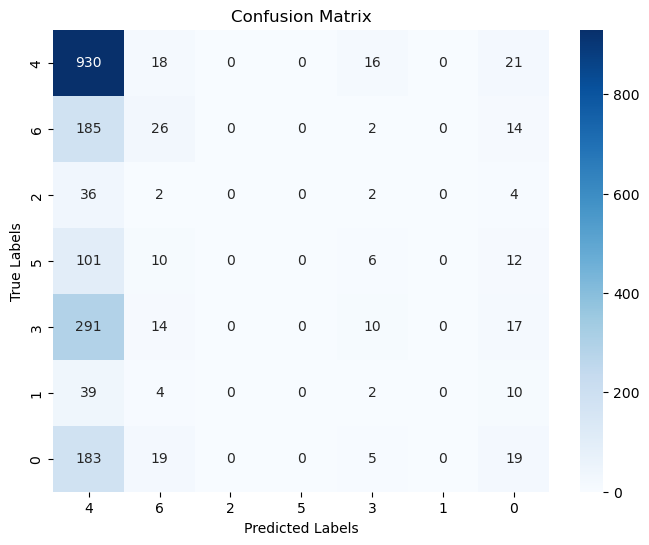

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get model predictions
y_pred = model.predict(X_val)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_val, axis=1)

# Generate confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotion_mapping.keys(), yticklabels=emotion_mapping.keys())
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

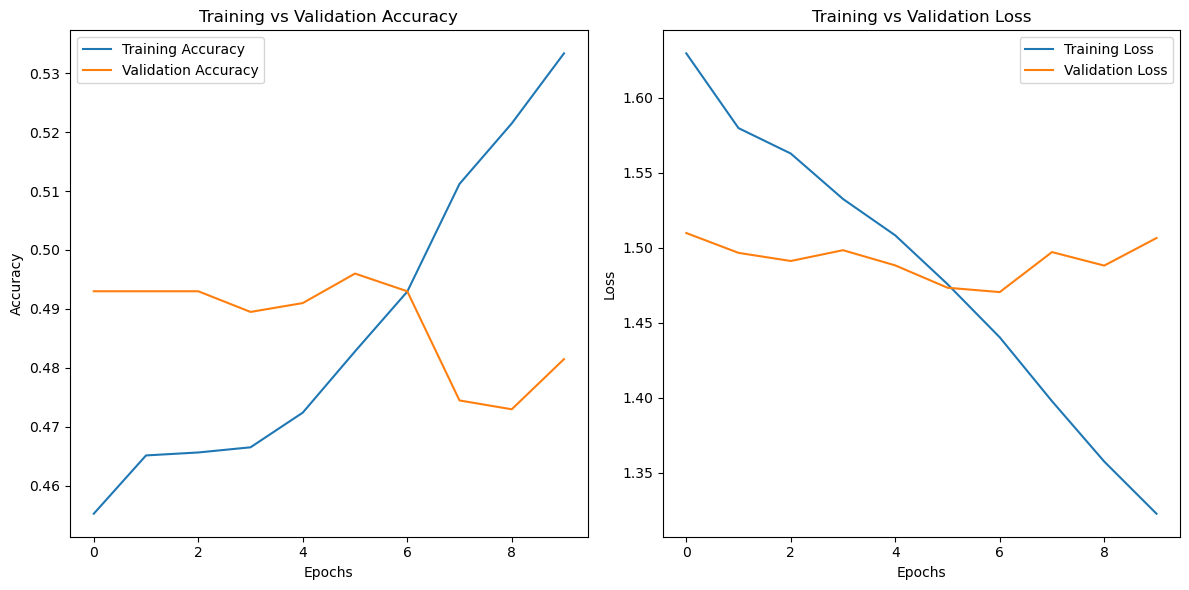

In [41]:
plt.figure(figsize=(12, 6))

# Plotting accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plotting loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

#### Refined Code for Audio File Listing

In [42]:
# Define paths to the audio directories
train_audio_dir = os.path.join(main_dataset, 'train', 'train_audio')
dev_audio_dir = os.path.join(main_dataset, 'dev', 'dev_audio')
test_audio_dir = os.path.join(main_dataset, 'test', 'test_audio')  # Assuming the audio files are in the 'test_audio' folder

def list_audio_files(directory, valid_extensions=None):
    if valid_extensions is None:
        valid_extensions = ['.wav', '.mp3']  # Default valid extensions

    if os.path.exists(directory):
        files = [f for f in os.listdir(directory) if any(f.endswith(ext) for ext in valid_extensions)]
        print(f"Audio files in '{directory}':")
        print(files[:10])  # Show only the first 10 files for brevity
    else:
        print(f"Directory '{directory}' does not exist!")

# List audio files in each directory
list_audio_files(train_audio_dir)
list_audio_files(dev_audio_dir)
list_audio_files(test_audio_dir)

Audio files in 'D:\ML & AI\Main Research\MELD\train\train_audio':
['dia0_utt0.mp3', 'dia0_utt1.mp3', 'dia0_utt10.mp3', 'dia0_utt11.mp3', 'dia0_utt12.mp3', 'dia0_utt13.mp3', 'dia0_utt2.mp3', 'dia0_utt3.mp3', 'dia0_utt4.mp3', 'dia0_utt5.mp3']
Audio files in 'D:\ML & AI\Main Research\MELD\dev\dev_audio':
['dia0_utt0.mp3', 'dia0_utt1.mp3', 'dia100_utt0.mp3', 'dia101_utt0.mp3', 'dia102_utt0.mp3', 'dia102_utt1.mp3', 'dia103_utt0.mp3', 'dia103_utt1.mp3', 'dia103_utt2.mp3', 'dia103_utt3.mp3']
Directory 'D:\ML & AI\Main Research\MELD\test\test_audio' does not exist!


In [43]:
import librosa
import numpy as np
import os
from tqdm import tqdm

# Function to extract MFCC features from an audio file
def extract_mfcc(file_path, n_mfcc=13, max_pad_len=200):
    # Load audio file
    audio, sample_rate = librosa.load(file_path, sr=None)
    
    # Extract MFCC features
    mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc)
    
    # Pad or truncate MFCC features to ensure consistent length across all files
    if mfcc.shape[1] < max_pad_len:
        pad_width = max_pad_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, ((0, 0), (0, pad_width)), mode='constant')
    else:
        mfcc = mfcc[:, :max_pad_len]
    
    return mfcc

# Function to process all audio files in a directory and extract their MFCC features
def process_audio_directory(directory, valid_extensions=None, n_mfcc=13, max_pad_len=200):
    if valid_extensions is None:
        valid_extensions = ['.wav', '.mp3']  # Default valid extensions
    
    mfcc_features = []
    file_names = []
    
    for file_name in tqdm(os.listdir(directory), desc=f"Processing {directory}"):
        # Check for valid audio file extensions
        if any(file_name.endswith(ext) for ext in valid_extensions):
            file_path = os.path.join(directory, file_name)
            mfcc = extract_mfcc(file_path, n_mfcc, max_pad_len)
            mfcc_features.append(mfcc)
            file_names.append(file_name)
    
    return np.array(mfcc_features), file_names

# Example usage: Process train, dev, and test directories
train_mfcc, train_files = process_audio_directory(train_audio_dir)
dev_mfcc, dev_files = process_audio_directory(dev_audio_dir)

# Check the shape of the MFCC features
print(f"Train MFCC shape: {train_mfcc.shape}")
print(f"Dev MFCC shape: {dev_mfcc.shape}")

Processing D:\ML & AI\Main Research\MELD\train\train_audio: 100%|██████████| 9988/9988 [06:21<00:00, 26.18it/s]
Processing D:\ML & AI\Main Research\MELD\dev\dev_audio: 100%|██████████| 1108/1108 [00:38<00:00, 28.77it/s]

Train MFCC shape: (9988, 13, 200)
Dev MFCC shape: (1108, 13, 200)


In [44]:
import librosa
import numpy as np
import os
from tqdm import tqdm

# Directory containing audio files
audio_dir = r"D:\ML & AI\Main Research\MELD\train\train_audio"
output_audio_features_path = r"D:\ML & AI\Main Research\MELD\train\audio_features.npy"

# Function to extract MFCC features from audio files
def extract_mfcc(file_path, n_mfcc=13, max_pad_len=200):
    try:
        audio, sample_rate = librosa.load(file_path, sr=None)
        mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc)
        if mfcc.shape[1] < max_pad_len:
            pad_width = max_pad_len - mfcc.shape[1]
            mfcc = np.pad(mfcc, ((0, 0), (0, pad_width)), mode='constant')
        else:
            mfcc = mfcc[:, :max_pad_len]
        return mfcc.flatten()
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Process all audio files in the directory
def process_audio_directory(directory, valid_extensions=None, n_mfcc=13, max_pad_len=200):
    if valid_extensions is None:
        valid_extensions = ['.wav', '.mp3']  # Supported audio formats
    
    features_dict = {}
    for file_name in tqdm(os.listdir(directory), desc="Processing Audio Files"):
        if any(file_name.endswith(ext) for ext in valid_extensions):
            file_path = os.path.join(directory, file_name)
            mfcc = extract_mfcc(file_path, n_mfcc, max_pad_len)
            if mfcc is not None:
                features_dict[file_name] = mfcc
    return features_dict

# Extract and save audio features
print("Extracting audio features...")
audio_features = process_audio_directory(audio_dir)
print(f"Saving audio features to {output_audio_features_path}...")
np.save(output_audio_features_path, audio_features)
print("Audio features saved.")

Extracting audio features...


Processing Audio Files: 100%|██████████| 9988/9988 [04:59<00:00, 33.39it/s]


Saving audio features to D:\ML & AI\Main Research\MELD\train\audio_features.npy...
Audio features saved.


#### Refined Code for Extracting Video Features:

In [45]:
pip install tensorflow opencv-python tqdm

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [46]:
import os
import cv2
import numpy as np
from concurrent.futures import ThreadPoolExecutor
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tqdm import tqdm
import multiprocessing

# Initialize a lighter model (MobileNetV2)
def init_model():
    print("Initializing MobileNetV2 model...")
    return MobileNetV2(weights="imagenet", include_top=False, pooling="avg")

# Extract frames from a video file
def extract_frames(video_path, frame_rate=150, max_frames=50):
    try:
        video_cap = cv2.VideoCapture(video_path)
        if not video_cap.isOpened():
            raise ValueError(f"Cannot open video file: {video_path}")

        frames = []
        count = 0
        while True:
            ret, frame = video_cap.read()
            if not ret:
                break
            if count % frame_rate == 0:
                frames.append(cv2.resize(frame, (224, 224)))
            count += 1
            if len(frames) >= max_frames:
                break
        video_cap.release()
        return np.array(frames)
    except Exception as e:
        print(f"Error processing video {video_path}: {e}")
        return None

# Process a single video file
def process_video(video_file, video_dir, model, frame_rate, max_frames, skipped_videos):
    video_path = os.path.join(video_dir, video_file)
    frames = extract_frames(video_path, frame_rate, max_frames)
    if frames is None or len(frames) == 0:
        skipped_videos.append(video_file)
        return video_file, None
    batch = preprocess_input(frames.astype(np.float32))
    features = model.predict(batch, verbose=0)
    return video_file, np.mean(features, axis=0)

# Parallel feature extraction
def extract_features_parallel(video_dir, model, frame_rate=150, max_frames=50, num_workers=16):
    video_files = [f for f in os.listdir(video_dir) if f.endswith(".mp4")]
    features_dict = {}
    skipped_videos = []

    with ThreadPoolExecutor(max_workers=num_workers) as executor:
        futures = [
            executor.submit(process_video, video_file, video_dir, model, frame_rate, max_frames, skipped_videos)
            for video_file in video_files
        ]
        for future in tqdm(futures, desc="Processing Videos"):
            video_file, features = future.result()
            if features is not None:
                features_dict[video_file] = features

    # Log skipped videos
    if skipped_videos:
        print(f"\nSkipped {len(skipped_videos)} videos:")
        print("\n".join(skipped_videos))

    return features_dict

# Main function
def main(video_dir, output_feature_path, frame_rate=150, max_frames=50, num_workers=16):
    print("Loading model...")
    model = init_model()
    print("Extracting features...")
    video_features = extract_features_parallel(video_dir, model, frame_rate, max_frames, num_workers)
    print("Saving features...")
    np.save(output_feature_path, video_features)
    print(f"Features saved to {output_feature_path}")

# Parameters
video_dir = r"D:\ML & AI\Main Research\MELD\train\train_video"
output_feature_path = r"D:\ML & AI\Main Research\MELD\train\video_features.npy"
num_workers = multiprocessing.cpu_count()

if __name__ == "__main__":
    main(video_dir, output_feature_path, frame_rate=150, max_frames=50, num_workers=num_workers)

Loading model...
Initializing MobileNetV2 model...
Extracting features...


Processing Videos:   7%|▋         | 673/9989 [03:53<2:02:52,  1.26it/s]

Error processing video D:\ML & AI\Main Research\MELD\train\train_video\dia125_utt3.mp4: Cannot open video file: D:\ML & AI\Main Research\MELD\train\train_video\dia125_utt3.mp4


Processing Videos: 100%|██████████| 9989/9989 [1:26:31<00:00,  1.92it/s]



Skipped 1 videos:
dia125_utt3.mp4
Saving features...
Features saved to D:\ML & AI\Main Research\MELD\train\video_features.npy


### Prepare the Data

##### Combine Features:

. Audio Features

. Video Features

In [54]:
import os
import numpy as np

# Paths to the feature files
audio_feature_path = r"D:\ML & AI\Main Research\MELD\train\audio_features.npy"
video_feature_path = r"D:\ML & AI\Main Research\MELD\train\video_features.npy"
output_combined_features_path = r"D:\ML & AI\Main Research\MELD\train\combined_features.npy"
output_aligned_files_path = r"D:\ML & AI\Main Research\MELD\train\aligned_files.npy"

# Check if files exist
if not os.path.exists(audio_feature_path):
    raise FileNotFoundError(f"Audio features file not found: {audio_feature_path}")
if not os.path.exists(video_feature_path):
    raise FileNotFoundError(f"Video features file not found: {video_feature_path}")

# Load features
audio_features = np.load(audio_feature_path, allow_pickle=True).item()
video_features = np.load(video_feature_path, allow_pickle=True).item()

# Function to combine features
def combine_audio_video_features(audio_features, video_features):
    """
    Combine audio and video features based on file names.
    Args:
        audio_features (dict): Dictionary of audio features.
        video_features (dict): Dictionary of video features.
    Returns:
        combined_features (np.ndarray): Combined features (audio + video).
        aligned_files (list): List of file names with both audio and video features.
    """
    combined_features = []
    aligned_files = []

    # Find common keys (file names)
    common_keys = set(audio_features.keys()) & set(video_features.keys())

    for key in common_keys:
        # Concatenate audio and video features
        combined_feature = np.concatenate([audio_features[key], video_features[key]])
        combined_features.append(combined_feature)
        aligned_files.append(key)

    return np.array(combined_features), aligned_files

# Combine features
print("Combining audio and video features...")
combined_features, aligned_files = combine_audio_video_features(audio_features, video_features)

# Save the combined features
print("Saving combined features...")
np.save(output_combined_features_path, combined_features)
np.save(output_aligned_files_path, aligned_files)
print(f"Combined features saved to {output_combined_features_path}")
print(f"Aligned files saved to {output_aligned_files_path}")

Combining audio and video features...
Saving combined features...
Combined features saved to D:\ML & AI\Main Research\MELD\train\combined_features.npy
Aligned files saved to D:\ML & AI\Main Research\MELD\train\aligned_files.npy


#### Normalize Features

In [55]:
import numpy as np

# Load features
audio_features_path = r"D:\ML & AI\Main Research\MELD\train\audio_features.npy"
video_features_path = r"D:\ML & AI\Main Research\MELD\train\video_features.npy"

audio_features = np.load(audio_features_path, allow_pickle=True).item()
video_features = np.load(video_features_path, allow_pickle=True).item()

# Normalize features
def normalize_features(features_dict, method='z-score'):
    """
    Normalize features using specified method.
    Args:
        features_dict (dict): Dictionary of features to normalize.
        method (str): Normalization method ('z-score' or 'min-max').
    Returns:
        dict: Normalized features dictionary.
    """
    normalized_features = {}
    all_features = np.array(list(features_dict.values()))
    
    if method == 'z-score':
        mean = np.mean(all_features, axis=0)
        std = np.std(all_features, axis=0)
        for key, features in features_dict.items():
            normalized_features[key] = (features - mean) / (std + 1e-8)  # Add epsilon to avoid division by zero
    elif method == 'min-max':
        min_val = np.min(all_features, axis=0)
        max_val = np.max(all_features, axis=0)
        for key, features in features_dict.items():
            normalized_features[key] = (features - min_val) / (max_val - min_val + 1e-8)
    else:
        raise ValueError("Unsupported normalization method. Use 'z-score' or 'min-max'.")
    
    return normalized_features

# Normalize both audio and video features
normalized_audio_features = normalize_features(audio_features, method='z-score')
normalized_video_features = normalize_features(video_features, method='z-score')

# Save normalized features
np.save(r"D:\ML & AI\Main Research\MELD\train\normalized_audio_features.npy", normalized_audio_features)
np.save(r"D:\ML & AI\Main Research\MELD\train\normalized_video_features.npy", normalized_video_features)

print("Normalized features saved.")

Normalized features saved.


### Build the Multi-Modal Neural Network Model

In [56]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Concatenate, BatchNormalization

def build_multimodal_model(audio_input_dim, video_input_dim, output_dim, task_type="classification"):
    """
    Build a multi-modal neural network model.
    Args:
        audio_input_dim (int): Dimension of audio features.
        video_input_dim (int): Dimension of video features.
        output_dim (int): Number of output classes or 1 for regression.
        task_type (str): "classification" or "regression".
    Returns:
        model (tf.keras.Model): Compiled multi-modal model.
    """
    # Audio input and processing
    audio_input = Input(shape=(audio_input_dim,), name="Audio_Input")
    audio_dense = Dense(128, activation="relu")(audio_input)
    audio_dropout = Dropout(0.3)(audio_dense)
    audio_bn = BatchNormalization()(audio_dropout)

    # Video input and processing
    video_input = Input(shape=(video_input_dim,), name="Video_Input")
    video_dense = Dense(128, activation="relu")(video_input)
    video_dropout = Dropout(0.3)(video_dense)
    video_bn = BatchNormalization()(video_dropout)

    # Feature fusion
    concatenated = Concatenate(name="Feature_Fusion")([audio_bn, video_bn])
    fusion_dense = Dense(128, activation="relu")(concatenated)
    fusion_dropout = Dropout(0.3)(fusion_dense)

    # Output layer
    if task_type == "classification":
        output_activation = "softmax" if output_dim > 1 else "sigmoid"
        output = Dense(output_dim, activation=output_activation, name="Output")(fusion_dropout)
    elif task_type == "regression":
        output = Dense(1, activation=None, name="Output")(fusion_dropout)
    else:
        raise ValueError("Invalid task_type. Choose 'classification' or 'regression'.")

    # Build model
    model = Model(inputs=[audio_input, video_input], outputs=output)

    # Compile model
    loss = "categorical_crossentropy" if task_type == "classification" and output_dim > 1 else "binary_crossentropy"
    loss = loss if task_type == "classification" else "mean_squared_error"
    model.compile(optimizer="adam", loss=loss, metrics=["accuracy"] if task_type == "classification" else ["mse"])

    return model

# Example Usage
audio_input_dim = 128  # Adjust based on normalized audio features
video_input_dim = 128  # Adjust based on normalized video features
output_dim = 7         # Number of classes for classification (e.g., emotion categories)
task_type = "classification"  # Change to "regression" for regression tasks

model = build_multimodal_model(audio_input_dim, video_input_dim, output_dim, task_type)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 Audio_Input (InputLayer)       [(None, 128)]        0           []                               
                                                                                                  
 Video_Input (InputLayer)       [(None, 128)]        0           []                               
                                                                                                  
 dense (Dense)                  (None, 128)          16512       ['Audio_Input[0][0]']            
                                                                                                  
 dense_1 (Dense)                (None, 128)          16512       ['Video_Input[0][0]']            
                                                                                              

### Visualize Training Results

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Example data preparation (replace with your actual data)
X_train = np.random.rand(1000, 50)  # Example features with 1000 samples and 50 features
y_train = np.random.randint(0, 7, 1000)  # Example labels with 7 classes
y_train = to_categorical(y_train, num_classes=7)

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Define the model
input_layer = Input(shape=(X_train.shape[1],), name="input_layer")
hidden_layer = Dense(128, activation='relu')(input_layer)
hidden_layer = Dropout(0.5)(hidden_layer)
output_layer = Dense(7, activation='softmax')(hidden_layer)

model = Model(inputs=input_layer, outputs=output_layer)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# Train the model
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val))

Epoch 1/10
25/25 [==============================] - 1s 11ms/step - loss: 2.0329 - accuracy: 0.1350 - val_loss: 1.9609 - val_accuracy: 0.1550
Epoch 2/10
25/25 [==============================] - 0s 2ms/step - loss: 1.9877 - accuracy: 0.1412 - val_loss: 1.9598 - val_accuracy: 0.1300
Epoch 3/10
25/25 [==============================] - 0s 2ms/step - loss: 1.9507 - accuracy: 0.1700 - val_loss: 1.9502 - val_accuracy: 0.1400
Epoch 4/10
25/25 [==============================] - 0s 2ms/step - loss: 1.9540 - accuracy: 0.1525 - val_loss: 1.9571 - val_accuracy: 0.1200
Epoch 5/10
25/25 [==============================] - 0s 2ms/step - loss: 1.9277 - accuracy: 0.1850 - val_loss: 1.9497 - val_accuracy: 0.1250
Epoch 6/10
25/25 [==============================] - 0s 2ms/step - loss: 1.9286 - accuracy: 0.1688 - val_loss: 1.9469 - val_accuracy: 0.1350
Epoch 7/10
25/25 [==============================] - 0s 2ms/step - loss: 1.9180 - accuracy: 0.1975 - val_loss: 1.9514 - val_accuracy: 0.1250
Epoch 8/10
25/25 [=

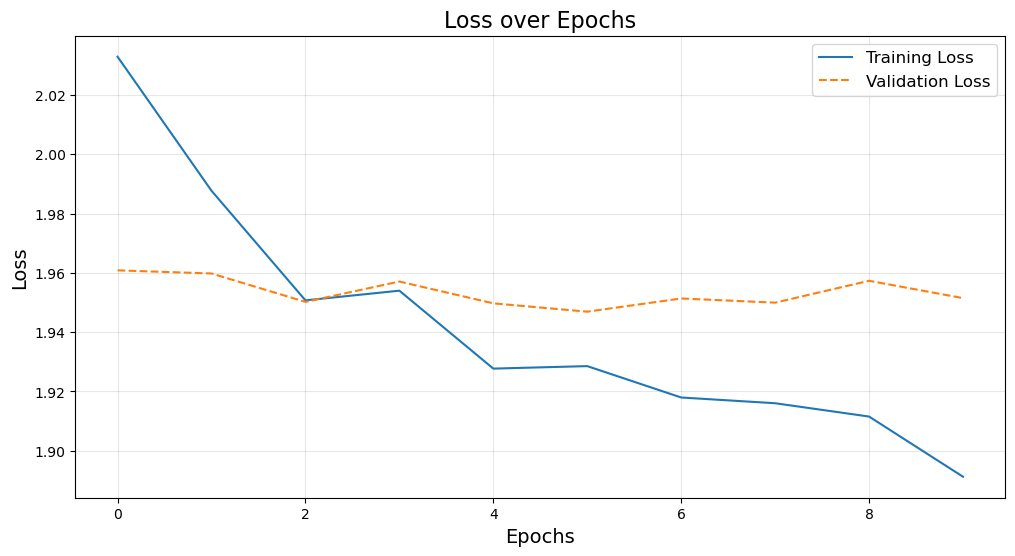

In [10]:
# Plot training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='--')
plt.title('Loss over Epochs', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

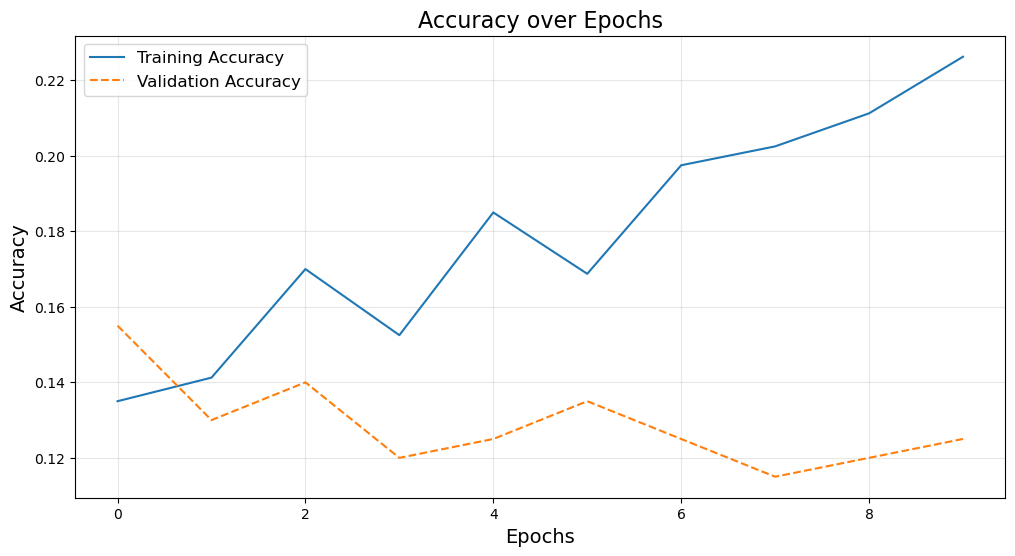

In [11]:
# Plot training and validation accuracy
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linestyle='--')
plt.title('Accuracy over Epochs', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

### Save the Model

In [12]:
# Save the model
model.save(r"D:\ML & AI\Main Research\MELD\multi_modal_model.h5")
print("Model saved successfully.")

Model saved successfully.
